# 1L2Tau — Consolidated Signal vs Background Analysis Pipeline

This notebook consolidates and reorganizes the separate, duplicated exploration
notebooks (`First_Training.ipynb`, `Combined_Runs.ipynb`, `Comparison.ipynb`,
`Yields.ipynb`) into a single, documented pipeline for the **1 lepton + 2 tau**
(1l2tau) channel.

Instead of copy-pasting the same loading / training / pruning code once per run
(as the original notebooks did), the logic is written **once** as a small library
of helper functions (Section 2), and each run just calls those functions. This
keeps the three tracks below consistent by construction instead of by
copy-paste discipline.

**Processes:** `signal_ggF` + `signal_VBF` (label = 1) vs. `Diboson`, `Zjets`,
`Wjets`, `ttbar`, `tops`, `SingleH`, `Vgamma`, `VVV` (label = 0).

**Preselection** (see repo `README.md`): `n_b_jet == 0` and `n_jet >= 2`.

**Physical event weight:** `w_phys = weight * weights` (`weight` = per-DSID/
campaign normalization, `weights` = Sherpa NLO generator weight, which can be
negative). `|w_phys|` is used for training/AUC; the sign is only relevant for
yields.

## Contents

1. Setup & global configuration (paths, preselection, leakage-free feature policy)
2. Shared helper function library (load/clean/yields/split/train/prune/tune/plot)
3. **Run 2 only** — load → yields → baseline → correlation pruning → Optuna tuning
4. **Run 3 only** — same steps as Run 2, independently
5. **Run 2 + Run 3 combined** — same steps on the chained sample, plus a
   comparison of the three tracks' feature rankings
6. **Run 2 vs Run 3 domain-shift check** — a separate classifier whose only job
   is telling Run 2 signal events apart from Run 3 signal events (AUC ≈ 0.5
   means the two campaigns are indistinguishable in the features that matter)
7. Summary — consolidated AUC comparison and saved artifacts

**Note:** this notebook is written to be run top-to-bottom, but has **not**
been executed yet — cell outputs (yields, AUCs, plots) will appear the first
time you run it against the ROOT files in `PPSSP_2026/1l2tau/`.


## 1. Setup & Global Configuration

Paths, tree name, preselection cut and the leakage-free feature-selection
policy. These are shared by every section below, so they're defined once,
here, instead of being re-declared (and risking drift) in each track.


In [15]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------

BASE_DIR_R2 = Path("PPSSP_2026/1l2tau/run2")   # 1 lepton + 2 taus, Run 2
BASE_DIR_R3 = Path("PPSSP_2026/1l2tau/run3")   # 1 lepton + 2 taus, Run 3
TREE_NAME   = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "1 Lepton 2 Taus")
# ---------------------------------------------------------------------------

PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background). The SAME 10 files
# are used for every track (Run 2, Run 3, combined) so results stay comparable.
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]   # raw branches; w_phys = their product
EVENT_ID_BRANCH = "eventNumber"        # bookkeeping only - NEVER a feature (see BLOCK_SUBSTR)

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy
# ---------------------------------------------------------------------------
# Load candidate branches generously and let XGBoost + correlation pruning
# narrow them down later, BUT never let these branches enter as *features* -
# they would poison training / leak the label:

#   - weights & scale/fake factors -> differ systematically signal vs bkg
#   - dsid / eventNumber           -> sample/event identifiers (label in disguise)
#   - *truth* / isTrue* / *fake*   -> generator info, absent in real data
#   - anti-tau bookkeeping         -> fake-region definition, process-dependent
#   - preselection constants       -> n_b_jet==0 always; pass1l2tau==1 always


BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig", "pass"]
BLOCK_EXACT = {
    "n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig",
}
BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:
    """True if `branch` is safe to use as a training feature (see policy above)."""
    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)


# ---------------------------------------------------------------------------
# Shared knobs - single named constants instead of literals scattered (and
# drifting) across cells.
# ---------------------------------------------------------------------------

TOP_N_IMPORTANCE = 30    # how many features to inspect after the baseline model
CORR_THRESH      = 0.75  # |corr| above this -> considered redundant
N_KEEP           = 20    # decorrelated features to keep after pruning
N_OPTUNA_TRIALS  = 15    # trials for every Optuna search in this notebook
N_FOLDS          = 5     # outer K-fold CV - fold = eventNumber % N_FOLDS, shared by
                         # every track/channel/run in this project (see assign_folds).
                         # Optuna's own internal CV reuses these SAME N_FOLDS folds
                         # (see run_optuna_search) rather than a fresh random split.
USE_GPU          = True  # device="cuda" - confirmed working on this machine (RTX 5090)

RANDOM_STATE = 42


## 2. Shared Helper Function Library

Every track below (Run 2, Run 3, combined, domain-shift) is built out of these
functions, so the logic exists exactly **once**:

- `discover_common_features`, `load_run_data`, `clean_data` — I/O + cleaning
- `compute_yields` — per-process yield / S over B table
- `make_train_val_split`, `make_fit_weights` — splitting & training weights
- `train_xgb_baseline`, `get_importance`, `plot_importance_bar` — baseline model
- `top_pairs`, `grouped_correlations`, `plot_group_correlations`,
  `prune_correlated` — correlation-based feature pruning
- `run_optuna_search`, `train_final_tuned_model`, `plot_optuna_diagnostics` —
  hyperparameter tuning


In [16]:
def discover_common_features(base_dirs, files=FILES, tree_name=TREE_NAME):

    """Branches common to EVERY process file in EVERY base_dir given, filtered
    through `is_feature`. Using the intersection (not just one file's branches)
    protects against a feature silently vanishing once samples/runs are
    concatenated.
    """

    common = None
    for base_dir in base_dirs:
        for fname, _ in files.values():
            keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
            common = keys if common is None else common & keys
    features = sorted(b for b in common if is_feature(b))
    print(f"{len(features)} candidate features (common to all {len(files)} processes x "
          f"{len(base_dirs)} run(s) = {len(files) * len(base_dirs)} files, leakage-free)")
    return features


def load_run_data(base_dir, run_label, features, files=FILES,
                   weight_parts=WEIGHT_PARTS, preselection=PRESELECTION,
                   tree_name=TREE_NAME, event_id_branch=EVENT_ID_BRANCH, verbose=True):
    
    """Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
      - run     : `run_label` (2 or 3) - bookkeeping only, NEVER a feature
      - eventNumber (or whatever `event_id_branch` is) : bookkeeping only,
        NEVER a feature (already excluded from `features` by is_feature's
        BLOCK_SUBSTR "eventnumber") - used solely by `assign_folds` to build
        the deterministic fold = eventNumber % N_FOLDS split shared by every
        track/channel/run/notebook in this project.
    """

    base_dir = Path(base_dir)
    dfs = []
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts + [event_id_branch], cut=preselection, library="pd")
        df["w_phys"] = df["weight"] * df["weights"]
        df["label"] = label
        df["process"] = proc
        df["run"] = run_label
        dfs.append(df)
        if verbose:
            print(f"Run {run_label} {proc:12s}: {len(df):>8d} events after preselection")
    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):

    """
    Post-concat cleaning, identical policy everywhere in this notebook:
      1) drop constant/empty features (zero variance -> no separation power)
      2) mask sentinel values (< -100, e.g. -999) to NaN - XGBoost routes NaN
         natively during training, so this is safe and avoids treating a
         missing-value code as if it were a real physical value.
    Returns (cleaned_data, updated_features) - operates on a copy, does not
    mutate the input DataFrame.
    """

    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        # The signal/background yield summary only applies to data that has
        # been through load_run_data (label/w_phys columns) - the domain-shift
        # section (Section 6) reuses this function on Run2-vs-Run3 data that
        # doesn't have those columns, so this part is skipped there.
        if "label" in data.columns and "w_phys" in data.columns:
            print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
                  f"background = {(data.label==0).sum()}")
            print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
                  f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features


In [17]:
def compute_yields(data, base_dir, files=FILES, tree_name=TREE_NAME,
                    weight_parts=WEIGHT_PARTS):
    
    """Per-process yield table (adapted from Yields.ipynb): for each process,
    report the raw MC event count, the pre-preselection ("skim") yield, the
    post-preselection event count and yield, and S/B bookkeeping.

    `data` must already be preselected + cleaned (as produced by
    `load_run_data` / `clean_data`); the pre-preselection numbers are obtained
    here with one cheap extra read of just the two weight branches (not the
    full feature set) per file.
    """

    base_dir = Path(base_dir)
    rows = []
    
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): tree_name})

        raw = tree.arrays(weight_parts, library="np")
        w_phys_skim = raw[weight_parts[0]] * raw[weight_parts[1]]

        sub = data.loc[data.process == proc]
        rows.append({
            "process":    proc,
            "is_signal":  label == 1,
            "N_mc":       tree.num_entries,
            "yield_skim": w_phys_skim.sum(),
            "N_presel":   len(sub),
            "yield":      sub["w_phys"].sum(),
            "sum_abs_w":  sub["w_phys"].abs().sum(),
            "frac_neg":   (sub["w_phys"] < 0).mean() if len(sub) else 0.0,
        })

    df = pd.DataFrame(rows)
    bkg_total = df.loc[~df.is_signal, "yield"].sum()
    sig_total = df.loc[df.is_signal, "yield"].sum()
    df["pct_of_bkg"] = np.where(~df.is_signal, 100 * df["yield"] / bkg_total, np.nan)
    df = df.sort_values(["is_signal", "yield"], ascending=[True, False])

    pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
    cols = ["process", "N_mc", "yield_skim", "N_presel", "yield", "pct_of_bkg", "frac_neg"]

    print(df[cols].to_string(index=False))
    print(f"\nTotal background (presel): {bkg_total:,.3f}")
    print(f"Total signal     (presel): {sig_total:,.3f}")
    print(f"S/B       = {sig_total/bkg_total:.2e}")
    print(f"S/sqrt(B) = {sig_total/np.sqrt(bkg_total):.4f}")

    return df


In [18]:
def assign_folds(df, event_col=EVENT_ID_BRANCH, n_folds=N_FOLDS):

    """Deterministic fold assignment: fold = eventNumber % n_folds. The SAME
    rule is applied identically across every notebook/channel/run/track in
    this project, so OOF score arrays stay event-aligned everywhere (this is
    what makes the paired per-fold AUC-delta comparisons in
    ModelComparison.ipynb possible). Always call this exact function on the
    exact `event_col` - never re-derive fold assignment ad hoc per notebook.
    """

    df = df.copy()
    df["fold"] = (df[event_col].to_numpy() % n_folds).astype("int8")
    return df


def compute_process_yield_targets(df, weight_col="w_phys", process_col="process"):

    """Full-sample SIGNED yield per process, computed ONCE on the complete
    dataset (every fold, before any negative-weight drop). This is the
    target every fold's training-set rescale preserves (see
    rescale_weights_by_yield) - computing it once here and reusing the same
    dict for all N_FOLDS folds (rather than recomputing it per fold on
    whatever ~4/5 of the data that fold's training set happens to contain)
    is what makes "every fold balances to the same target" true, which the
    single-fold weight-balance plot below relies on for being representative.
    """

    return df.groupby(process_col)[weight_col].sum().to_dict()


def rescale_weights_by_yield(df, target_yields, weight_col="w_phys",
                              process_col="process", min_target=1e-6):

    """Per-process: rescale the rows in `df` (already negative-weight
    filtered) so their weight-sum matches `target_yields[process]` - the
    process's TRUE full-sample signed yield, from `compute_process_yield_targets`
    called ONCE on the complete pre-split sample (NOT recomputed per fold -
    passing a fold-local `df` into compute_process_yield_targets instead of
    the full sample would reintroduce the per-fold MC-fraction dependence
    this rescale exists to remove).

    The guard is on the TARGET, not on `kept_sum`: a mostly-negative-weight
    process (e.g. tops, ~36% negative individual weights) can have a
    full-sample SIGNED yield that is itself small or even negative. Dividing
    a positive `kept_sum` by a negative/near-zero target would flip the sign
    of every kept weight in that process, handing negative sample weights to
    the trainer - exactly the failure this guard exists to prevent. If a
    process's target yield is <= min_target, clamp it to min_target and warn
    (naming the process) instead of silently propagating a negative or
    degenerate ratio.
    """

    df = df.copy()
    for proc, sub in df.groupby(process_col):
        target = target_yields.get(proc, sub[weight_col].sum())
        if target <= min_target:
            warnings.warn(
                f"rescale_weights_by_yield: process '{proc}' has full-sample "
                f"signed yield {target:.6g} <= {min_target:g} (mostly-negative "
                f"weights?) - clamping target to {min_target:g} to avoid a "
                f"negative/degenerate rescale factor."
            )
            target = min_target
        kept_sum = sub[weight_col].sum()
        if kept_sum != 0:
            df.loc[sub.index, weight_col] = sub[weight_col] * (target / kept_sum)
    return df


def make_fit_weights(labels, abs_weights, cell_ids=None):

    """Balance signal/background total weight (so the much larger background
    yield doesn't dominate the loss) and normalize the OVERALL mean weight to
    1. If `cell_ids` is given (e.g. a joint channel/run key), the
    signal/background balance is computed WITHIN each distinct cell_ids value
    FIRST, before the global mean-normalization - this stops whichever cell
    has the most MC events from dominating the pooled loss, and keeps each
    cell's own signal/background ratio meaningful (rather than the network
    implicitly learning p(signal|cell) baked into the loss). If `cell_ids` is
    None, balances signal/background globally only (single-cell behavior).
    `abs_weights` must already be non-negative.

    CANONICAL SOURCE: Final_Notebooks/PNN.ipynb. This function is
    copy-pasted BYTE-FOR-BYTE into every in-scope notebook (deliberately NOT
    a shared importable module in this pass - self-contained notebooks are
    wanted). Do not adapt/rename/"improve" a single copy without updating
    every other copy identically - see assert_fit_weights_balanced below for
    a cheap per-notebook check that this copy hasn't drifted.
    """

    labels = np.asarray(labels)
    fit_weights = np.asarray(abs_weights, dtype=float).copy()

    if cell_ids is None:
        sum_signal = fit_weights[labels == 1].sum()
        sum_background = fit_weights[labels == 0].sum()
        fit_weights[labels == 1] *= sum_background / sum_signal
    else:
        cell_ids = np.asarray(cell_ids)
        for cell in np.unique(cell_ids):
            m = cell_ids == cell
            sum_signal = fit_weights[m & (labels == 1)].sum()
            sum_background = fit_weights[m & (labels == 0)].sum()
            if sum_signal > 0:
                fit_weights[m & (labels == 1)] *= sum_background / sum_signal

    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def assert_fit_weights_balanced(fit_weights, labels, cell_ids):

    """Per-cell balance sanity check for make_fit_weights - fails loudly if
    THIS notebook's copy has drifted from the canonical PNN.ipynb version
    (e.g. someone edits one notebook's copy without updating every other
    one identically)."""

    labels = np.asarray(labels)
    cell_ids = np.asarray(cell_ids)
    cells = np.unique(cell_ids)
    sig_sums = [fit_weights[(labels == 1) & (cell_ids == c)].sum() for c in cells]
    bkg_sums = [fit_weights[(labels == 0) & (cell_ids == c)].sum() for c in cells]
    assert np.allclose(sig_sums, bkg_sums), (
        "make_fit_weights: per-cell balance broken - this copy has drifted "
        "from the canonical PNN.ipynb version"
    )


def n_eff_table(df, group_cols, weight_col="w_phys"):

    """Effective event count N_eff = (sum w)^2 / sum(w^2) per group - a
    sanity check that no small process (e.g. Run2 ttbar) is starved in any
    fold. Returns NaN (never raises/produces a silent inf) for a group with
    sum(w^2) == 0 (an empty group, or all-zero weights in that fold) -
    exactly the degenerate case this table exists to catch.
    """

    def _n_eff(w):
        w = np.asarray(w, dtype=float)
        denom = (w ** 2).sum()
        if denom == 0:
            return np.nan
        return (w.sum()) ** 2 / denom

    return df.groupby(list(group_cols))[weight_col].apply(_n_eff).rename("n_eff")


def plot_weight_balance(y, w_before, w_after, title="", save_path=None):

    """Panel A: overlaid per-event weight histograms (signal vs background),
    before vs after `make_fit_weights` balancing, log-y. Panel B: grouped bar
    chart of summed weight (signal total vs background total), before vs
    after. `w_before`/`w_after` must correspond to the SAME rows (e.g.
    `train_df["w_phys"]` post yield-rescale/pre-balance vs `w_train_fit`
    post-balance) for a fair comparison. Called ONCE per track on a single
    representative fold's training split - valid as representative of every
    fold ONLY because `rescale_weights_by_yield` uses one full-sample target
    shared by all folds (see its docstring).
    """

    y = np.asarray(y)
    w_before = np.asarray(w_before, dtype=float)
    w_after = np.asarray(w_after, dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    lo = min(w_before.min(), w_after.min())
    hi = max(w_before.max(), w_after.max())
    bins = np.linspace(lo, hi, 60)
    ax.hist(w_before[y == 1], bins=bins, histtype="step", linestyle="--",
            color="crimson", linewidth=1.6, alpha=0.7, label="signal (before)")
    ax.hist(w_before[y == 0], bins=bins, histtype="step", linestyle="--",
            color="steelblue", linewidth=1.6, alpha=0.7, label="background (before)")
    ax.hist(w_after[y == 1], bins=bins, histtype="step", linestyle="-",
            color="crimson", linewidth=1.8, label="signal (after)")
    ax.hist(w_after[y == 0], bins=bins, histtype="step", linestyle="-",
            color="steelblue", linewidth=1.8, label="background (after)")
    ax.set_yscale("log")
    ax.set_xlabel("per-event weight")
    ax.set_ylabel("events (log scale)")
    ax.set_title("Per-event weight distribution")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1]
    sums_before = [w_before[y == 1].sum(), w_before[y == 0].sum()]
    sums_after = [w_after[y == 1].sum(), w_after[y == 0].sum()]
    x = np.arange(2)
    width = 0.35
    b1 = ax.bar(x - width / 2, sums_before, width, label="before", color="lightgray", edgecolor="black")
    b2 = ax.bar(x + width / 2, sums_after, width, label="after", color="steelblue")
    ax.bar_label(b1, fmt="%.3g", fontsize=8)
    ax.bar_label(b2, fmt="%.3g", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(["signal", "background"])
    ax.set_ylabel("summed weight")
    ax.set_title("Total weight: signal vs background")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
    plt.show()


def prepare_fold_data(data, features, target_yields, cell_cols=(), n_folds=N_FOLDS, k=0):

    """Build the train/val/test row partitions and per-row training weights
    for outer-fold rotation `k`: test=(fold==k), val=(fold==(k+1)%n_folds),
    train=the remaining n_folds-2 folds.

    TRAIN and VAL (early-stopping): negative-w_phys rows dropped, the kept
    rows rescaled per-process to the FULL-SAMPLE signed yield
    (`target_yields`, from compute_process_yield_targets called ONCE on the
    complete pre-split sample - NOT recomputed here), then `make_fit_weights`
    balances per `cell_cols` x class cell and mean-normalizes globally.

    EVAL/TEST (`test_df`): ALL rows of that fold, nothing dropped. Callers
    must use |w_phys| for AUC/ROC and signed w_phys for yields/significance/
    histograms - this function only returns the row partition, not a choice
    of metric.
    """

    val_fold = (k + 1) % n_folds
    test_mask = data["fold"] == k
    val_mask = data["fold"] == val_fold
    train_mask = ~(test_mask | val_mask)

    train_full = data.loc[train_mask]
    val_full = data.loc[val_mask]

    train_keep = train_full.loc[train_full["w_phys"] >= 0].copy()
    val_keep = val_full.loc[val_full["w_phys"] >= 0].copy()

    train_keep = rescale_weights_by_yield(train_keep, target_yields)
    val_keep = rescale_weights_by_yield(val_keep, target_yields)

    def _cell_ids(df):
        if not cell_cols:
            return None
        return df[list(cell_cols)].astype(str).agg("_".join, axis=1).to_numpy()

    cell_train = _cell_ids(train_keep)
    w_train_fit = make_fit_weights(train_keep["label"].to_numpy(), train_keep["w_phys"].to_numpy(), cell_ids=cell_train)
    if cell_train is not None:
        assert_fit_weights_balanced(w_train_fit, train_keep["label"].to_numpy(), cell_train)

    cell_val = _cell_ids(val_keep)
    w_val_fit = make_fit_weights(val_keep["label"].to_numpy(), val_keep["w_phys"].to_numpy(), cell_ids=cell_val)

    return {
        "k": k, "val_fold": val_fold,
        "train_df": train_keep, "val_df": val_keep, "test_df": data.loc[test_mask].copy(),
        "w_train_fit": w_train_fit, "w_val_fit": w_val_fit,
        "n_dropped_train": len(train_full) - len(train_keep),
        "n_dropped_val": len(val_full) - len(val_keep),
    }


In [19]:
def train_xgb_baseline(X_train, y_train, w_train, X_val, y_val, w_val,
                        label="", use_gpu=USE_GPU, random_state=RANDOM_STATE):
    """Fit the standard baseline XGBoost classifier (500 trees, depth 6, early
    stopping on weighted AUC) used throughout this notebook.

    Training weights: |w_phys| (negative Sherpa weights would corrupt the
    boosting gradients), class-balanced and mean-normalized via
    `make_fit_weights`. Returns (model, auc_train, auc_val).
    """
    w_abs_train = np.abs(w_train.to_numpy())
    sum_sig, sum_bkg = w_abs_train[y_train == 1].sum(), w_abs_train[y_train == 0].sum()
    w_fit = make_fit_weights(y_train.to_numpy(), w_abs_train)
    w_val_fit = np.abs(w_val.to_numpy())

    print(f"[{label}] signal weight scale factor: {sum_bkg/sum_sig:.1f}")

    params = dict(
        n_estimators=500, learning_rate=0.10, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", eval_metric=["logloss", "auc"],
        early_stopping_rounds=30, n_jobs=-1, random_state=random_state,
    )
    if use_gpu:
        params["device"] = "cuda"

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train, sample_weight=w_fit,
        eval_set=[(X_val, y_val)], sample_weight_eval_set=[w_val_fit],
        verbose=50,
    )

    auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1], sample_weight=w_abs_train)
    auc_val   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1],   sample_weight=w_val_fit)
    print(f"[{label}] best_iteration={model.best_iteration} | "
          f"weighted AUC: train={auc_train:.4f} val={auc_val:.4f}")
    return model, auc_train, auc_val


def train_xgb_fold(X_train, y_train, w_train_fit, X_val, y_val, w_val_abs, params=None, label=""):

    """K-fold counterpart of train_xgb_baseline: fits one XGBClassifier fold
    model given ALREADY-PREPARED weights (`w_train_fit` from
    `prepare_fold_data`/`make_fit_weights`, `w_val_abs` = plain |w_phys| for
    early stopping) - does NOT recompute weights itself, unlike
    train_xgb_baseline. `params` (if given) overrides the default
    hyperparameters below (e.g. with an Optuna-tuned dict from
    `params_from_study`).
    """

    p = dict(n_estimators=500, learning_rate=0.10, max_depth=6, subsample=0.8,
              colsample_bytree=0.8, tree_method="hist", eval_metric=["logloss", "auc"],
              early_stopping_rounds=30, n_jobs=-1, random_state=RANDOM_STATE)
    if params:
        p.update(params)
    if USE_GPU:
        p["device"] = "cuda"

    model = xgb.XGBClassifier(**p)
    model.fit(X_train, y_train, sample_weight=w_train_fit,
              eval_set=[(X_val, y_val)], sample_weight_eval_set=[w_val_abs], verbose=False)

    auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1], sample_weight=w_train_fit)
    auc_val = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1], sample_weight=w_val_abs)
    print(f"[{label}] best_iteration={model.best_iteration} | weighted AUC: train={auc_train:.4f} val={auc_val:.4f}")
    return model, auc_train, auc_val


def get_importance(model, features):
    """total_gain / gain / weight importance table for `features`, sorted by
    total_gain (best metric for ranking - unlike plain `weight`, it isn't
    inflated just because a feature was split on many times)."""
    booster = model.get_booster()
    imp = pd.DataFrame({
        t: booster.get_score(importance_type=t) for t in ["total_gain", "gain", "weight"]
    }).reindex(features).fillna(0.0)
    imp = imp.sort_values("total_gain", ascending=False)
    imp["gain_frac"] = imp["total_gain"] / imp["total_gain"].sum()
    return imp


def plot_importance_bar(imp, top_n=30, title="", color="steelblue"):
    """Horizontal bar chart of the top `top_n` features by gain_frac."""
    n = min(top_n, len(imp))
    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp["gain_frac"].head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Fraction of total gain")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [20]:
def top_pairs(corr, thr=0.50):
    """Feature pairs with |Pearson correlation| > thr, most-correlated first."""
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]


def grouped_correlations(data, feats, group_col, group_values):
    """Pearson correlation of `feats`, computed separately for each value of
    `group_col` (e.g. label 0/1 for background/signal, or run_label 0/1 for
    Run2/Run3) - correlations genuinely differ between groups, so pruning
    must look at both, not just the pooled correlation.
    """
    return {v: data.loc[data[group_col] == v, feats].corr() for v in group_values}


def plot_group_correlations(corrs, names, feats, suptitle=""):
    """Side-by-side correlation heatmaps, one per entry in `corrs`/`names`."""
    fig, axes = plt.subplots(1, len(corrs), figsize=(11 * len(corrs), 10), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, corr, name in zip(axes, corrs, names):
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, rotation=90, fontsize=7)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=7)
        ax.set_title(name)
    fig.colorbar(im, ax=list(axes), shrink=0.8, label="Pearson correlation")
    if suptitle:
        fig.suptitle(suptitle)
    plt.show()


def prune_correlated(top_feats, corr_max, corr_thresh=CORR_THRESH, n_keep=N_KEEP):

    """
    Walk `top_feats` (most -> least important). Keep a feature unless it is
    more than `corr_thresh` correlated with a more-important feature already
    kept (i.e. it's redundant with something better). Stop once `n_keep`
    survivors are found.
    """
    
    kept, dropped = [], []
    for feat in top_feats:
        redundant_with = next((k for k in kept if corr_max.loc[feat, k] > corr_thresh), None)
        if redundant_with is None:
            kept.append(feat)
        else:
            dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
        if len(kept) == n_keep:
            break

    if len(kept) < n_keep:
        print(f"WARNING: only {len(kept)}/{n_keep} survivors found within the top "
              f"{len(top_feats)} candidates - raise the candidate pool or lower corr_thresh.")

    print(f"Kept {len(kept)} decorrelated features (most -> least important):")
    for i, feat in enumerate(kept, 1):
        print(f"  {i:2d}. {feat}")
    print(f"\nDropped {len(dropped)} redundant features (|corr| > {corr_thresh} with a more important feature):")
    for feat, because_of, corr_val in dropped:
        print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

    return kept, dropped


In [21]:
def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """
    Max Asimov significance over score cuts. Uses SIGNED w_phys (expected
    yields, not |w_phys|). `min_bkg` guards the sparse high-score tail where
    Z is unstable when B is tiny or negative. Treat Z as a RELATIVE metric
    for ranking models/hyperparameters on identical rows, not an absolute
    discovery number (it depends on sample normalization/luminosity).

    This is the OPTUNA OBJECTIVE for every model in this project (XGBoost
    and the neural nets) - chosen for consistency so the headline BDT-vs-NN
    comparison isn't partly an artifact of the two being tuned for different
    metrics. AUC is still reported/plotted as a post-hoc diagnostic
    (run_kfold_xgb, plot_oof_roc) but does NOT drive hyperparameter selection.
    """

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None
    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
        if z > best_z:
            best_z, best_t = z, t
    return best_z, best_t


def run_optuna_search(data, features, target_yields, cell_cols=(), n_trials=N_OPTUNA_TRIALS,
                      n_folds=N_FOLDS, base_n_estimators=800, study_name="xgb_opt", seed=RANDOM_STATE):

    """
    Bayesian hyperparameter search (TPE sampler + median pruning), scored by
    mean expected significance (Asimov Z, in the high-score tail - see
    `significance_scan`) over the SAME eventNumber-based `fold` column used
    for the final OOF rotation (`assign_folds`) - NOT AUC, and NOT a fresh
    random StratifiedKFold like the old (pre-k-fold-refactor) version of
    this function used. Significance (not AUC) is the objective for EVERY
    model in this project (XGBoost and the neural nets) so the final
    BDT-vs-NN comparison is tuned consistently - see significance_scan's
    docstring.

    KNOWN, ACCEPTED LEAK - NOT NESTED CV: hyperparameters are chosen using
    all `n_folds` folds' mean Z, and those SAME `n_folds` folds later
    produce the final OOF scores (via run_kfold_xgb) - so each fold's model
    inherits a hyperparameter choice that was informed by (among others) its
    own held-out fold. This is deliberately accepted as the standard
    practical compromise (mild, since hyperparameter selection is
    low-information relative to a full model fit) - do NOT mistake this for
    a clean nested-CV setup; it is intentionally not one.

    Per-fold training weights use the SAME recipe as the final OOF loop
    (`prepare_fold_data`: drop negative w_phys, rescale to the full-sample
    per-process yield, `make_fit_weights` per-cell) so the Optuna-selected
    hyperparameters are tuned under conditions matching final training.
    """

    def objective(trial):
        params = {
            "n_estimators": base_n_estimators,
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 50.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.60, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
            "tree_method": "hist",
            "eval_metric": "auc",  # early-stopping metric for tree count only, NOT the Optuna objective
            "early_stopping_rounds": 50,
            "n_jobs": -1,
            "random_state": seed,
        }
        if USE_GPU:
            params["device"] = "cuda"

        fold_zs, best_iterations = [], []
        for k in range(n_folds):
            fd = prepare_fold_data(data, features, target_yields, cell_cols=cell_cols, n_folds=n_folds, k=k)
            fold_model = xgb.XGBClassifier(**params)
            fold_model.fit(
                fd["train_df"][features], fd["train_df"]["label"], sample_weight=fd["w_train_fit"],
                eval_set=[(fd["val_df"][features], fd["val_df"]["label"])],
                sample_weight_eval_set=[fd["w_val_fit"]], verbose=False,
            )
            test_df = fd["test_df"]
            pred = fold_model.predict_proba(test_df[features])[:, 1]
            z, _ = significance_scan(test_df["label"].to_numpy(), pred, test_df["w_phys"].to_numpy())
            fold_zs.append(z)
            best_iterations.append(fold_model.best_iteration + 1)

            trial.report(float(np.mean(fold_zs)), step=k)
            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("mean_best_iteration", int(round(np.mean(best_iterations))))
        trial.set_user_attr("fold_zs", [float(v) for v in fold_zs])
        return float(np.mean(fold_zs))

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
        study_name=study_name,
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, gc_after_trial=True)

    print(f"\n[{study_name}] completed trials: {len(study.trials)}")
    print(f"[{study_name}] best mean CV significance Z ({n_folds} eventNumber-folds): {study.best_value:.5f}")
    print(f"[{study_name}] mean best iteration: {study.best_trial.user_attrs['mean_best_iteration']}")
    print(f"[{study_name}] fold Z's: {study.best_trial.user_attrs['fold_zs']}")
    print(f"[{study_name}] best parameters:")
    for name, value in study.best_params.items():
        print(f"    {name}: {value}")
    return study


def params_from_study(study, seed=RANDOM_STATE):
    """Extract the frozen hyperparameter dict from a completed Optuna study
    (best_params + the CV-selected tree count), ready to pass as
    `run_kfold_xgb`'s `best_params` argument. Hyperparameters are frozen
    across all outer folds - never re-tuned per fold (see run_optuna_search)."""
    return {
        **study.best_params,
        "n_estimators": study.best_trial.user_attrs["mean_best_iteration"],
        "random_state": seed,
    }


def plot_optuna_diagnostics(study, title_suffix=""):

    """2-panel diagnostic: Optuna trial history + hyperparameter importance.
    (The old 3rd "holdout ROC" panel doesn't apply under the k-fold refactor
    - there is no single holdout anymore; use plot_oof_roc on the OOF
    DataFrame from run_kfold_xgb instead.)
    """

    trials = study.trials_dataframe()
    complete = trials.loc[trials["state"] == "COMPLETE"].copy()
    param_importance = optuna.importance.get_param_importances(study)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    axes[0].plot(complete["number"], complete["value"], "o", alpha=0.7)
    axes[0].plot(complete["number"], complete["value"].cummax(), color="black", linewidth=2, label="best so far")
    axes[0].set(xlabel="Trial", ylabel="Mean CV significance Z (eventNumber-folds)", title=f"Optuna history {title_suffix}")
    axes[0].legend()

    names = list(param_importance)
    values = [param_importance[name] for name in names]
    axes[1].barh(names[::-1], values[::-1], color="steelblue")
    axes[1].set(xlabel="Optuna parameter importance", title="Hyperparameter importance")

    plt.show()


def run_kfold_xgb(data, features, best_params, target_yields, cell_cols=(), n_folds=N_FOLDS, label=""):

    """5-fold rotation: for k in range(n_folds), test=fold k,
    val=fold (k+1)%n_folds, train=the remaining folds. Hyperparameters
    (`best_params`, from a single prior Optuna run - see run_optuna_search /
    params_from_study) stay FROZEN across all folds - never re-tuned per
    fold. Returns (oof_df, models): `oof_df` covers 100% of `data`'s rows
    (every event scored by a model that never trained on it) with columns
    [score, eventNumber, fold, label, process, run, w_phys]; `models` is the
    list of n_folds fitted XGBClassifiers (one per fold, in fold order).
    """

    oof_scores = np.full(len(data), np.nan)
    models = []

    for k in range(n_folds):
        fd = prepare_fold_data(data, features, target_yields, cell_cols=cell_cols, n_folds=n_folds, k=k)

        w_val_abs = np.abs(fd["val_df"]["w_phys"].to_numpy())
        model, auc_train, auc_val = train_xgb_fold(
            fd["train_df"][features], fd["train_df"]["label"], fd["w_train_fit"],
            fd["val_df"][features], fd["val_df"]["label"], w_val_abs,
            params=best_params, label=f"{label} fold{k}",
        )
        models.append(model)

        test_df = fd["test_df"]
        pred = model.predict_proba(test_df[features])[:, 1]
        oof_scores[np.flatnonzero((data["fold"] == k).to_numpy())] = pred

        auc_test = roc_auc_score(test_df["label"], pred, sample_weight=test_df["w_phys"].abs())
        z_test, _ = significance_scan(test_df["label"].to_numpy(), pred, test_df["w_phys"].to_numpy())
        print(f"[{label}] fold {k}: test_fold={k} val_fold={fd['val_fold']} | "
              f"train n={len(fd['train_df'])} (dropped {fd['n_dropped_train']} neg) | "
              f"test weighted AUC = {auc_test:.4f} | test significance Z = {z_test:.3f}")

    oof_df = data[["process", "run", "label", "fold", EVENT_ID_BRANCH, "w_phys"]].copy()
    oof_df["score"] = oof_scores

    oof_auc = roc_auc_score(oof_df["label"], oof_df["score"], sample_weight=oof_df["w_phys"].abs())
    oof_z, oof_thr = significance_scan(oof_df["label"].to_numpy(), oof_df["score"].to_numpy(), oof_df["w_phys"].to_numpy())
    print(f"[{label}] OOF weighted AUC (pooled, every event scored by a model that never saw it) = {oof_auc:.4f}")
    print(f"[{label}] OOF max Asimov Z (pooled) = {oof_z:.3f} at score cut = {oof_thr:.4f}")

    return oof_df, models


def plot_oof_roc(oof_df, title=""):

    """OOF ROC over the full sample (every event scored by a model that
    never trained on it), plus a fold-spread band (per-fold ROC curves
    interpolated onto a common FPR grid, shaded min-max across folds)."""

    y = oof_df["label"].to_numpy()
    s = oof_df["score"].to_numpy()
    w = oof_df["w_phys"].abs().to_numpy()
    fpr, tpr, _ = roc_curve(y, s, sample_weight=w)
    auc = roc_auc_score(y, s, sample_weight=w)

    grid = np.linspace(0, 1, 200)
    fold_tprs = []
    for k in sorted(oof_df["fold"].unique()):
        sub = oof_df[oof_df["fold"] == k]
        if sub["label"].nunique() < 2:
            continue
        f_k, t_k, _ = roc_curve(sub["label"], sub["score"], sample_weight=sub["w_phys"].abs())
        fold_tprs.append(np.interp(grid, f_k, t_k))
    fold_tprs = np.array(fold_tprs)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"OOF ROC (AUC={auc:.4f})")
    if len(fold_tprs):
        ax.fill_between(grid, fold_tprs.min(axis=0), fold_tprs.max(axis=0), color="steelblue",
                         alpha=0.2, label="fold spread (min-max)")
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set(xlabel="False-positive rate", ylabel="True-positive rate", title=title, xlim=(0, 1), ylim=(0, 1))
    ax.legend(loc="lower right")
    plt.show()
    return auc


def save_track_artifacts(models, features, best_params, oof_df, base_dir, track_name):

    """Persist the 5 (model) fold artifacts + the exact feature list + the
    frozen hyperparameters + the OOF score array - "which features did the
    tuned Run 3 model use" must be answerable from disk, not from notebook
    state. Replaces the old single final_model_*.json / splits/{train,val}.root."""

    base_dir = Path(base_dir)
    base_dir.mkdir(parents=True, exist_ok=True)
    for k, model in enumerate(models):
        model.save_model(base_dir / f"model_{track_name}_fold{k}.json")
    with open(base_dir / f"features_{track_name}.json", "w") as f:
        json.dump(features, f)
    with open(base_dir / f"hyperparams_{track_name}.json", "w") as f:
        json.dump(best_params, f)
    oof_path = base_dir / f"oof_scores_{track_name}.csv"
    oof_df.to_csv(oof_path, index=False)
    print(f"Saved {len(models)} fold models + feature list + hyperparams + OOF scores -> {base_dir}/ (track={track_name})")


## 3. Run 2 — Solo Track

Load, explore and train on **Run 2 only**. Every step below is a call into
the Section 2 helper library, so this whole track is intentionally short.


In [22]:
# ---- Load & clean (Run 2) ---------------------------------------------------
features_r2 = discover_common_features([BASE_DIR_R2])
data_r2 = load_run_data(BASE_DIR_R2, run_label=2, features=features_r2)
data_r2, features_r2 = clean_data(data_r2, features_r2)
data_r2 = assign_folds(data_r2, n_folds=N_FOLDS)
print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}):")
print(data_r2["fold"].value_counts().sort_index())
data_r2.head()


80 candidate features (common to all 10 processes x 1 run(s) = 10 files, leakage-free)
Run 2 signal_ggF  :    67075 events after preselection
Run 2 signal_VBF  :    21639 events after preselection
Run 2 Diboson     :   312600 events after preselection
Run 2 Zjets       :   141863 events after preselection
Run 2 Wjets       :    31272 events after preselection
Run 2 ttbar       :     7335 events after preselection
Run 2 tops        :    62238 events after preselection
Run 2 SingleH     :    11124 events after preselection
Run 2 Vgamma      :    21510 events after preselection
Run 2 VVV         :    14028 events after preselection
Dropped 16 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_decayMode', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_decayMode']

64 final features
Total: 690684 events | signal = 88714 | backgroun

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_phi,tau2_pt,weight,weights,eventNumber,w_phys,label,process,run,fold
0,"486,197.281","437,935.438","350,626.938","42,837.090","91,098.922","44,471.410","77,389.633","91,956.719","12,270.166",2.849,...,-3.045,"22,102.740",0.001,-0.028,2978199,-0.000,1,signal_ggF,2,4
1,"233,307.375","192,779.188","92,852.828","31,019.406","71,547.602","68,906.953","35,689.703","32,890.672","20,957.582",2.693,...,1.528,"30,261.955",0.001,0.055,2979398,0.000,1,signal_ggF,2,3
2,"399,998.125","345,424.469","107,697.430","164,906.188","219,479.844","72,820.844","127,177.953","97,451.047","33,988.949",0.400,...,0.594,"33,664.312",0.001,0.030,8078473,0.000,1,signal_ggF,2,3
3,"344,867.656","249,412.125","165,593.328","21,953.850","117,409.383","61,864.949","36,656.707","111,334.617","18,972.348",2.709,...,0.694,"21,605.848",0.001,0.031,7227119,0.000,1,signal_ggF,2,4
4,"326,392.688","270,753.156","128,916.000","71,331.773","126,971.281","70,505.391","129,401.234","129,401.234","55,308.082",2.955,...,-1.724,"31,729.717",0.001,0.032,28478259,0.000,1,signal_ggF,2,4


In [23]:
# ---- Yields / S over B (Run 2) ----------------------------------------------
yields_r2 = compute_yields(data_r2, BASE_DIR_R2)


   process   N_mc  yield_skim  N_presel     yield  pct_of_bkg  frac_neg
     Wjets  74455  39,768.937     31272 5,698.655      49.695     0.158
     Zjets 308295  20,845.893    141863 3,582.158      31.238     0.154
     ttbar  58930   7,962.950      7335   994.253       8.670     0.004
   Diboson 621842   2,379.632    312600   730.367       6.369     0.062
    Vgamma  53058   1,400.002     21510   276.489       2.411     0.079
      tops 512118     914.310     62238   120.914       1.054     0.363
   SingleH 130938     333.658     11124    59.853       0.522     0.005
       VVV  43008      13.026     14028     4.598       0.040     0.002
signal_ggF 133971       3.381     67075     1.757         NaN     0.060
signal_VBF  47257       0.150     21639     0.068         NaN     0.001

Total background (presel): 11,467.287
Total signal     (presel): 1.824
S/B       = 1.59e-04
S/sqrt(B) = 0.0170


Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2WeightBalance.png


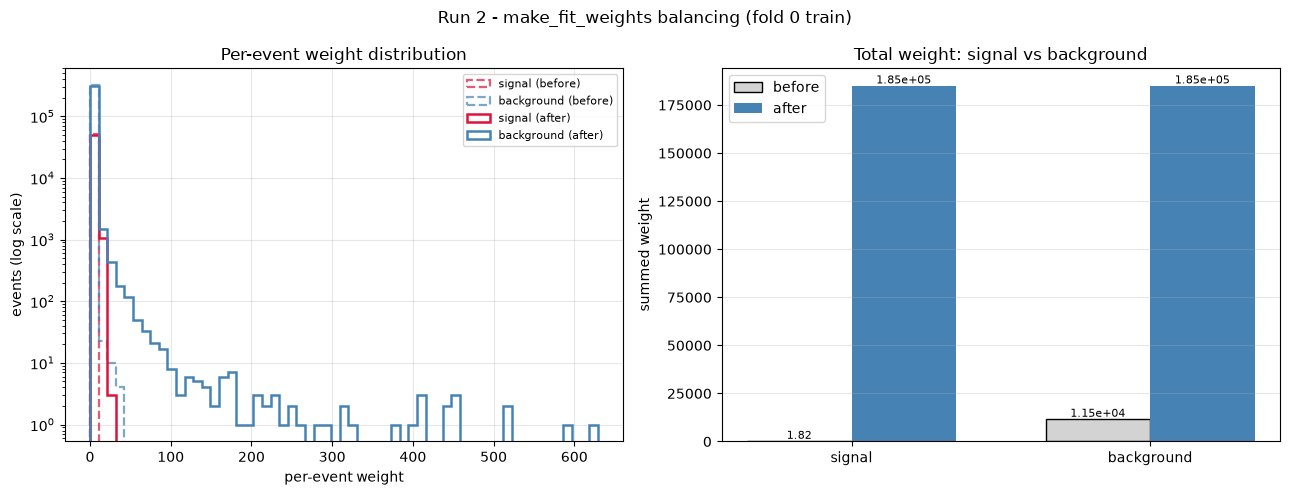

N_eff (training sample, positive-only, post yield-rescale) by label - fold 0:
label
0    4,765.992
1   27,507.190
Name: n_eff, dtype: float64

N_eff (eval sample, signed, FULL fold-0 test partition) by label:
label
0     956.475
1   7,398.000
Name: n_eff, dtype: float64

Dropped 44813 negative-w_phys training rows in this preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).


In [24]:
# ---- Weight-balance diagnostics (Run 2, representative fold 0) --------------
# Replaces the old 80/10/10 make_train_val_split + persisted train/val.root -
# there is no single train/val split anymore, only the 5-fold rotation used
# below (run_kfold_xgb). This cell previews fold 0 (test=fold 0, val=fold 1,
# train=folds 2/3/4) purely to (a) show what make_fit_weights does to the
# training weights and (b) sanity-check N_eff per process/label is not
# starved in any fold - it does NOT produce a model used anywhere downstream.
target_yields_r2 = compute_process_yield_targets(data_r2)
fd0_r2 = prepare_fold_data(data_r2, features_r2, target_yields_r2, cell_cols=(), n_folds=N_FOLDS, k=0)

w_before_r2 = fd0_r2["train_df"]["w_phys"].to_numpy()   # post neg-drop + yield-rescale, PRE class-balance
w_after_r2 = fd0_r2["w_train_fit"]                        # POST make_fit_weights balance + normalize
y_preview_r2 = fd0_r2["train_df"]["label"].to_numpy()

PLOTS_DIR_R2 = BASE_DIR_R2 / "plots"
PLOTS_DIR_R2.mkdir(parents=True, exist_ok=True)
plot_weight_balance(
    y_preview_r2, w_before_r2, w_after_r2,
    title="Run 2 - make_fit_weights balancing (fold 0 train)",
    save_path=PLOTS_DIR_R2 / "Run2WeightBalance.png",
)

print("N_eff (training sample, positive-only, post yield-rescale) by label - fold 0:")
print(n_eff_table(fd0_r2["train_df"], ["label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by label:")
print(n_eff_table(fd0_r2["test_df"], ["label"]))
print(f"\nDropped {fd0_r2['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


[Run2 baseline (fold-0 preview)] best_iteration=317 | weighted AUC: train=0.9776 val=0.9339

Top 30 features by total gain (Run 2, fold-0 preview):
            total_gain  gain_frac  weight
HT_tau     539,413.938      0.325 429.000
tau1_pt    139,476.906      0.084 331.000
dR_t1t2     88,727.258      0.053 560.000
SumPt_t1t2  65,190.617      0.039 412.000
m_t1t2      47,649.859      0.029 595.000
met_sumet   46,671.574      0.028 455.000
dR_l1j1     45,480.363      0.027 401.000
tau2_pt     43,285.930      0.026 477.000
HT          41,458.762      0.025 274.000
m_l1j       34,357.516      0.021 390.000
met_met     28,154.498      0.017 457.000
m_l1j1      21,561.850      0.013 332.000
dR_t1t2_l1  19,913.613      0.012 367.000
m_ttl       18,435.402      0.011 323.000
m_l1t1      17,793.500      0.011 344.000
tau1_eta    17,037.193      0.010 418.000
dR_l1t      16,403.369      0.010 338.000
tau2_eta    16,126.308      0.010 415.000
m_l1t       15,594.808      0.009 348.000
dR_l1j2     

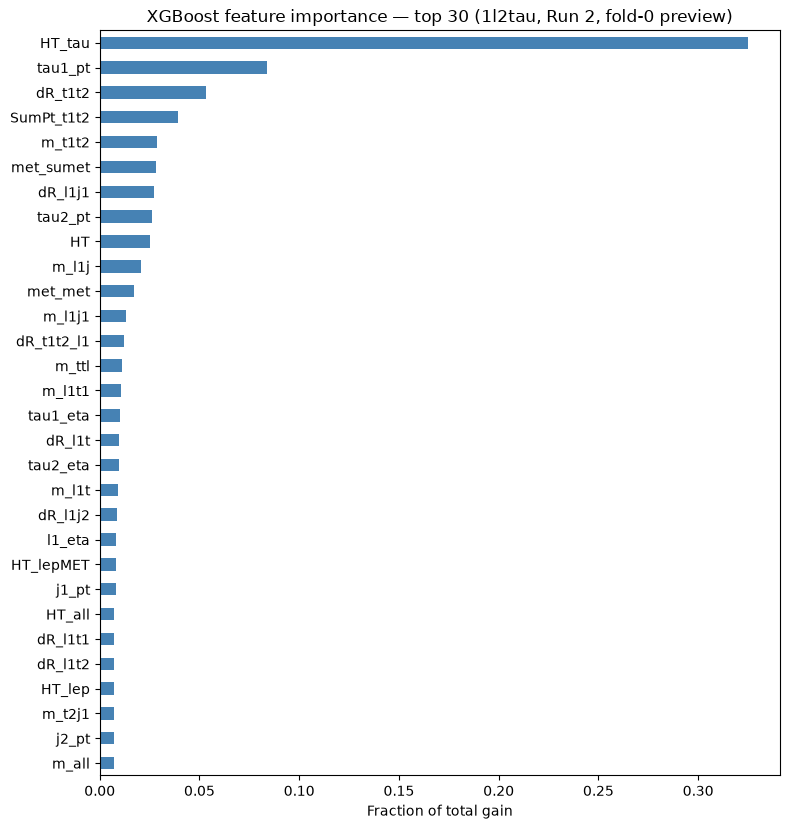

In [25]:
# ---- Baseline XGBoost + feature importance (Run 2, fold-0 preview) ---------
# Only used to RANK features for the correlation-pruning stage below - the
# actual 5 fold models (frozen hyperparameters, one per outer fold) are
# trained later by run_kfold_xgb.
model_r2, auc_train_r2, auc_val_r2 = train_xgb_fold(
    fd0_r2["train_df"][features_r2], fd0_r2["train_df"]["label"], fd0_r2["w_train_fit"],
    fd0_r2["val_df"][features_r2], fd0_r2["val_df"]["label"], np.abs(fd0_r2["val_df"]["w_phys"].to_numpy()),
    label="Run2 baseline (fold-0 preview)",
)

imp_r2 = get_importance(model_r2, features_r2)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Run 2, fold-0 preview):")
print(imp_r2[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_r2['total_gain'] == 0).sum()} / {len(features_r2)}")

plot_importance_bar(imp_r2, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (1l2tau, Run 2, fold-0 preview)")


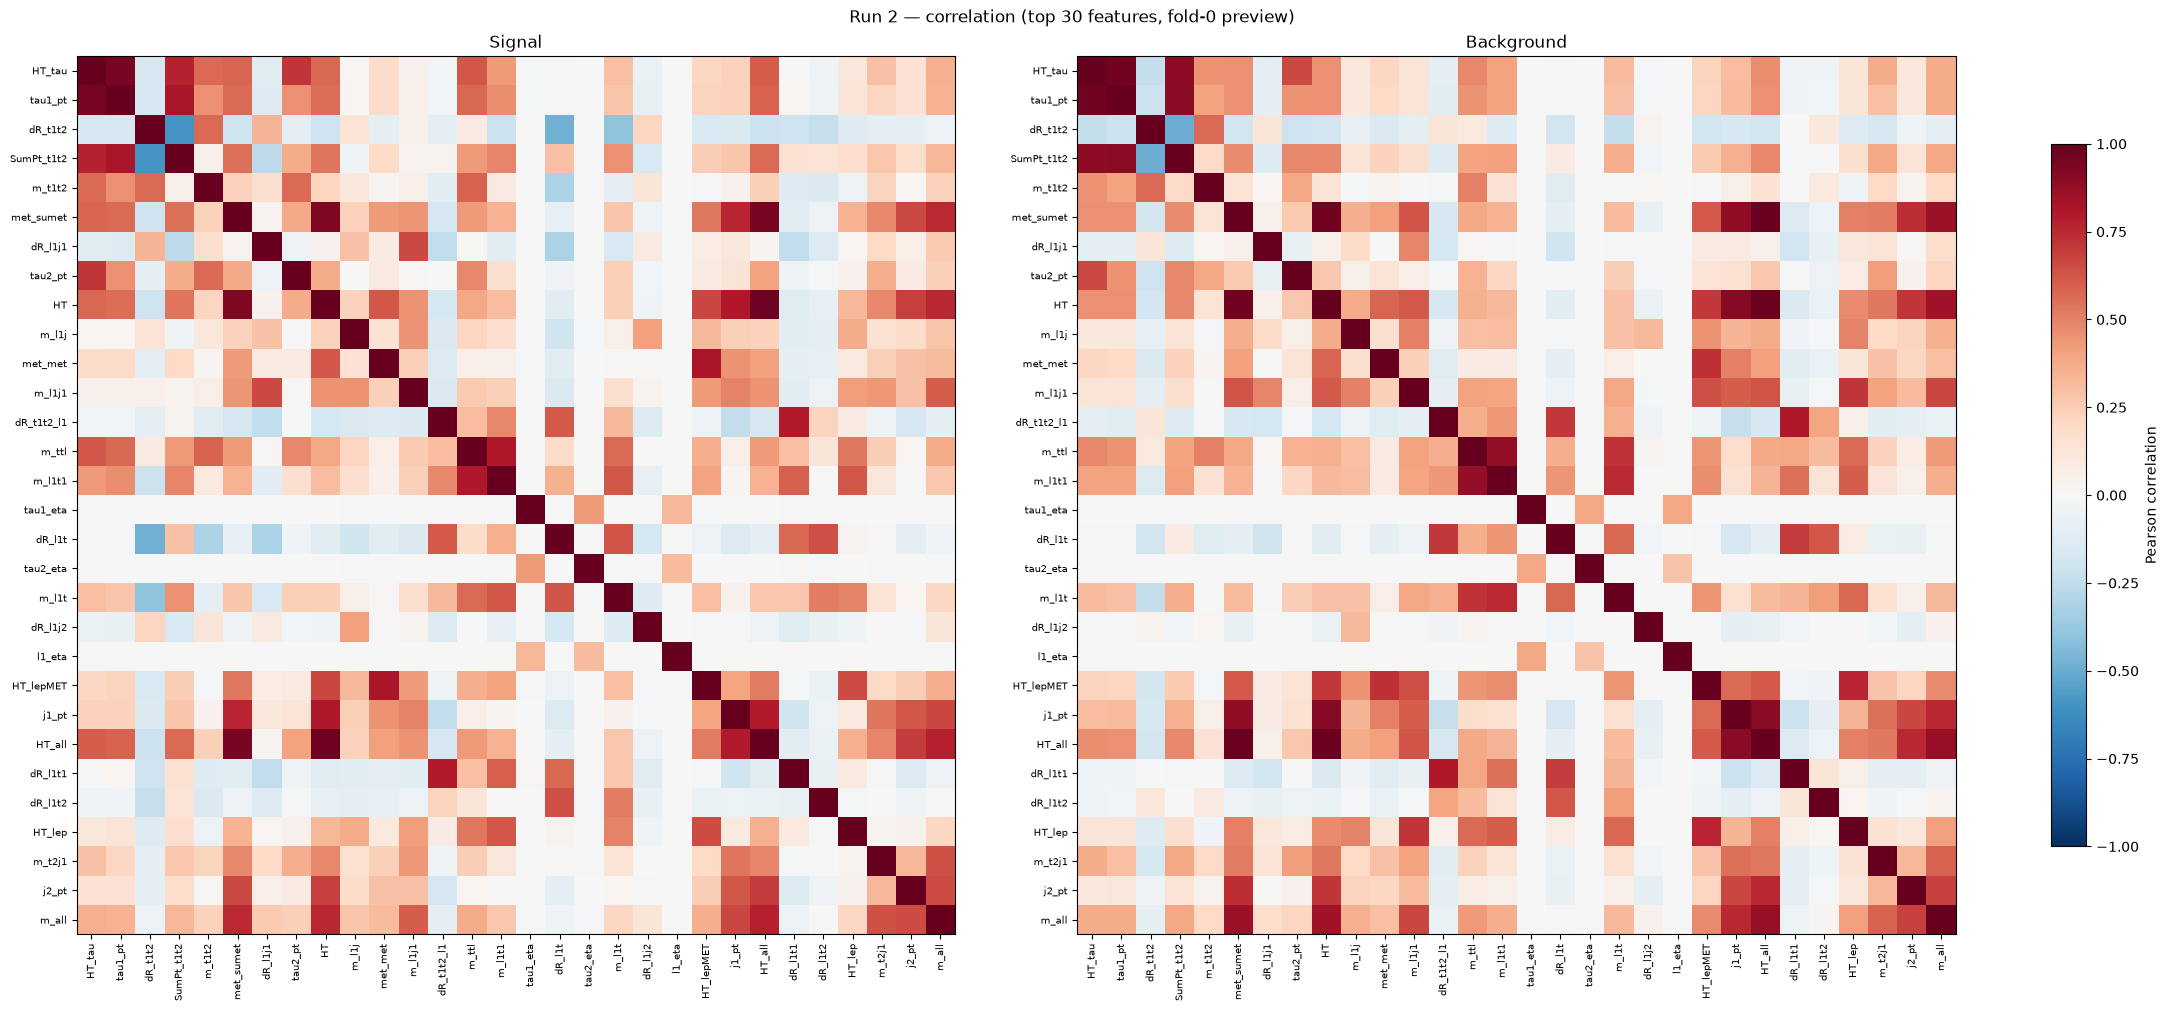

Pairs with |corr| > 0.50 (signal):
HT          HT_all       0.969
met_sumet   HT_all       0.952
HT_tau      tau1_pt      0.946
met_sumet   HT           0.932
tau1_pt     SumPt_t1t2   0.816
met_met     HT_lepMET    0.815
m_ttl       m_l1t1       0.804
HT          j1_pt        0.803
j1_pt       HT_all       0.795
dR_t1t2_l1  dR_l1t1      0.793
HT_all      m_all        0.778
HT_tau      SumPt_t1t2   0.773
met_sumet   j1_pt        0.762
HT          m_all        0.753
met_sumet   m_all        0.749
HT_tau      tau2_pt      0.718
HT_all      j2_pt        0.703
HT          j2_pt        0.682
j1_pt       m_all        0.671
HT          HT_lepMET    0.666
met_sumet   j2_pt        0.662
dR_l1j1     m_l1j1       0.658
HT_lepMET   HT_lep       0.654
j2_pt       m_all        0.651
dR_l1t      dR_l1t2      0.643
m_t2j1      m_all        0.634
dR_l1t      m_l1t        0.632
m_l1t1      HT_lep       0.625
HT          met_met      0.624
HT_tau      m_ttl        0.623
m_l1t1      m_l1t        0.621
j1_p

In [26]:
# ---- Correlation of the top features (Run 2, fold-0 preview train set) -----
# Pearson correlation among the TOP_N_IMPORTANCE most important features,
# separately for signal and background (correlations genuinely differ between
# the two by physics). Computed on the fold-0 preview TRAIN partition only
# (not the full data_r2), so no test-fold events leak into the ranking used
# to choose which features to keep.
top_feats_r2 = imp_r2.index[:TOP_N_IMPORTANCE].tolist()
corrs_r2 = grouped_correlations(fd0_r2["train_df"], top_feats_r2, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [corrs_r2[1], corrs_r2[0]], ["Signal", "Background"], top_feats_r2,
    suptitle=f"Run 2 — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_r2[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_r2[0]).to_string())


In [27]:
# ---- Correlation-based pruning to a decorrelated top-20 (Run 2) ------------
# Conservative combination: a pair counts as redundant if EITHER regime
# (signal or background) shows near-degeneracy.
corr_max_r2 = corrs_r2[1].abs().combine(corrs_r2[0].abs(), np.maximum)
PRUNED_FEATURES_R2, dropped_r2 = prune_correlated(top_feats_r2, corr_max_r2, CORR_THRESH, N_KEEP)


Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. dR_t1t2
   3. m_t1t2
   4. met_sumet
   5. dR_l1j1
   6. tau2_pt
   7. m_l1j
   8. met_met
   9. m_l1j1
  10. dR_t1t2_l1
  11. m_ttl
  12. tau1_eta
  13. dR_l1t
  14. tau2_eta
  15. m_l1t
  16. dR_l1j2
  17. l1_eta
  18. dR_l1t2
  19. HT_lep
  20. m_t2j1

Dropped 8 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.968)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.896)
  HT              -> redundant with met_sumet       (|corr| = 0.966)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.878)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.815)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.884)
  HT_all          -> redundant with met_sumet       (|corr| = 0.985)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.801)


[Run2 pruned (fold-0 preview)] best_iteration=232 | weighted AUC: train=0.9620 val=0.9250

Comparison (fold-0 preview) — full 64 features: val AUC = 0.9339 | pruned 20 features: val AUC = 0.9250


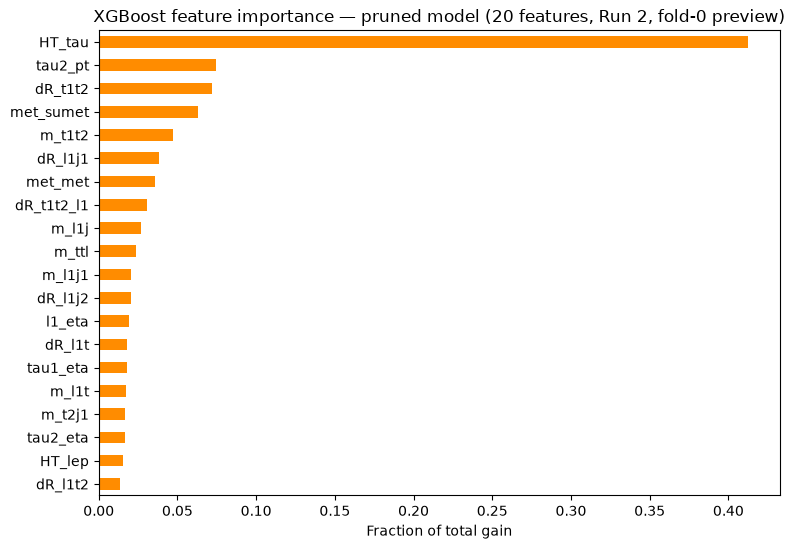

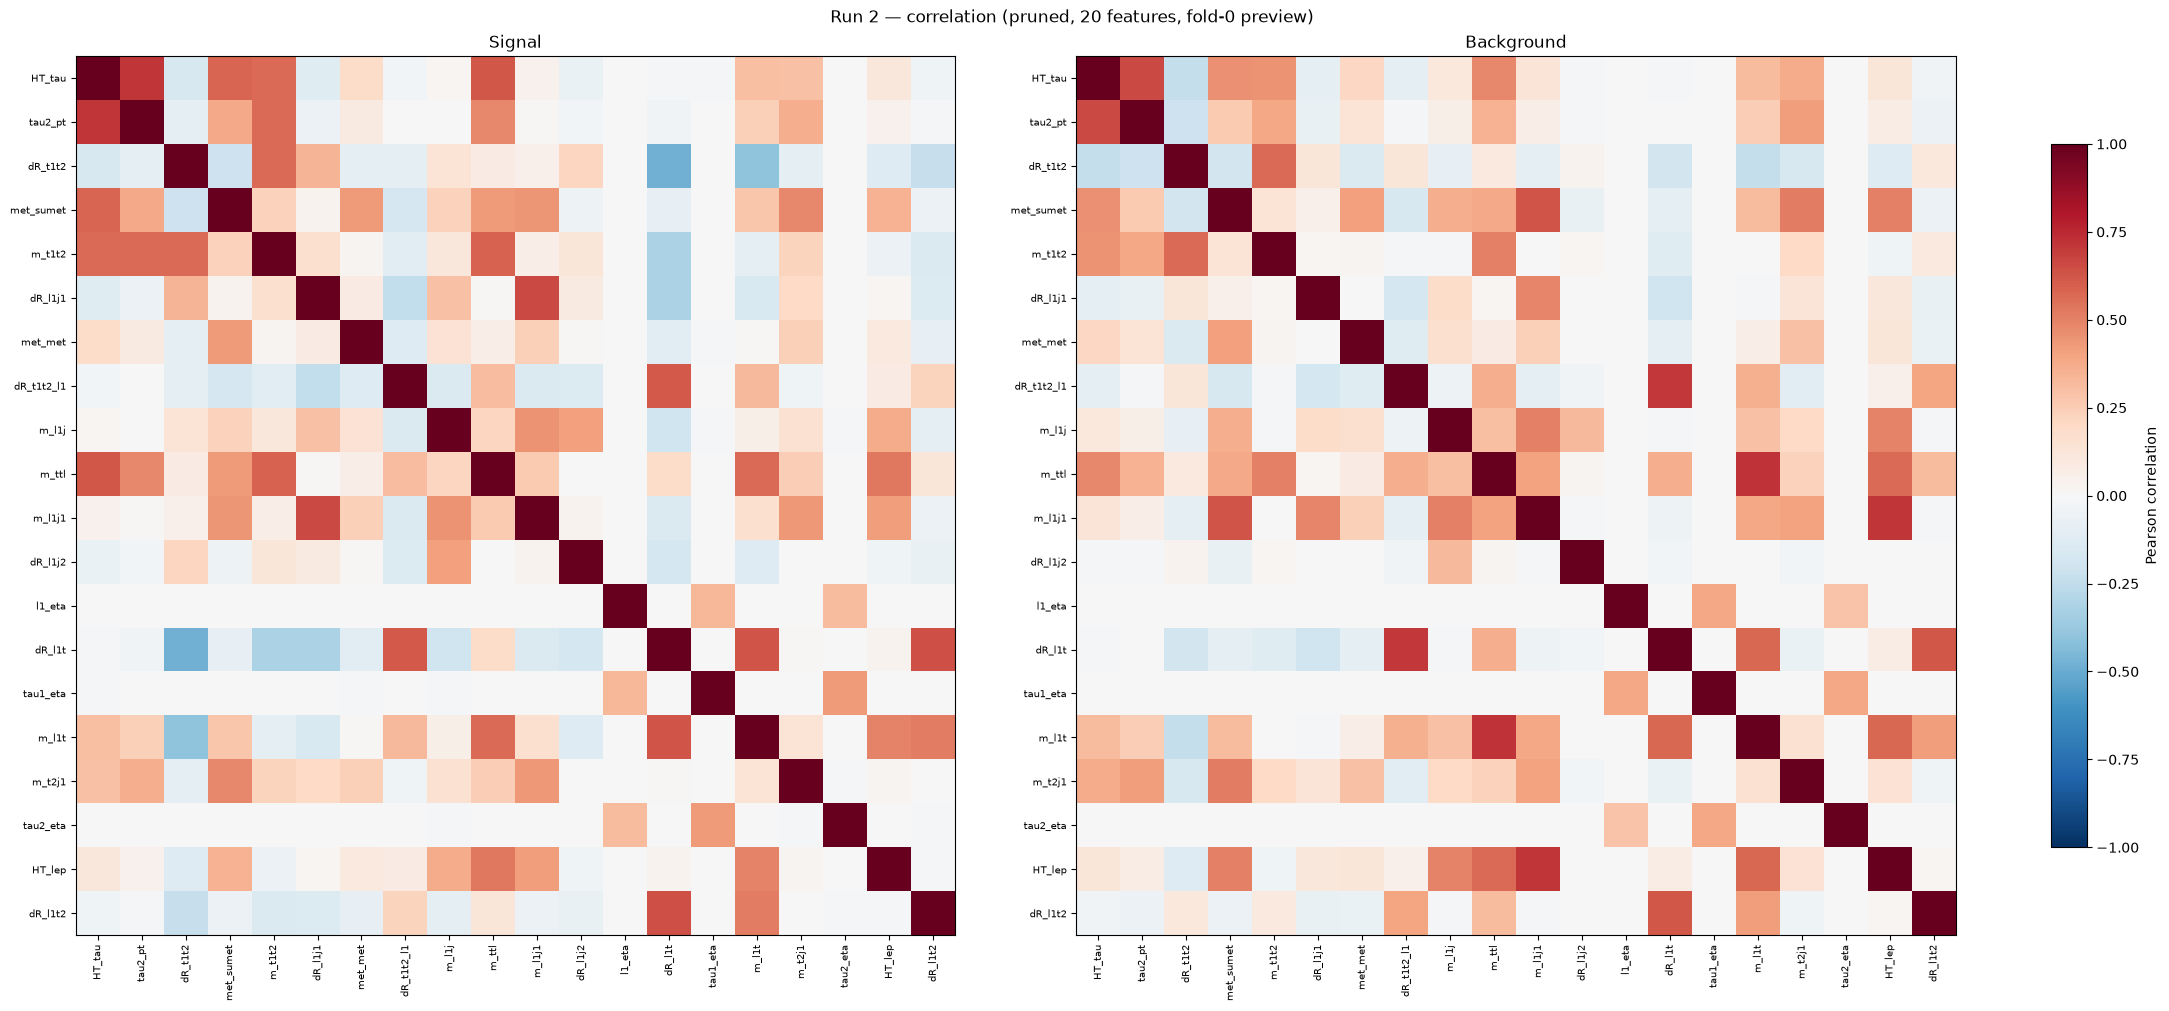

In [28]:
# ---- Retrain on the pruned feature set + re-check correlation (Run 2, fold-0 preview) ------
model_r2_pruned, auc_train_r2_pruned, auc_val_r2_pruned = train_xgb_fold(
    fd0_r2["train_df"][PRUNED_FEATURES_R2], fd0_r2["train_df"]["label"], fd0_r2["w_train_fit"],
    fd0_r2["val_df"][PRUNED_FEATURES_R2], fd0_r2["val_df"]["label"], np.abs(fd0_r2["val_df"]["w_phys"].to_numpy()),
    label="Run2 pruned (fold-0 preview)",
)

imp_r2_pruned = get_importance(model_r2_pruned, PRUNED_FEATURES_R2)
print(f"\nComparison (fold-0 preview) — full {len(features_r2)} features: val AUC = {auc_val_r2:.4f} | "
      f"pruned {len(PRUNED_FEATURES_R2)} features: val AUC = {auc_val_r2_pruned:.4f}")

plot_importance_bar(
    imp_r2_pruned, top_n=len(PRUNED_FEATURES_R2),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_R2)} features, Run 2, fold-0 preview)",
    color="darkorange",
)

pruned_top_feats_r2 = imp_r2_pruned.index.tolist()
pruned_corrs_r2 = grouped_correlations(fd0_r2["train_df"], pruned_top_feats_r2, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_r2[1], pruned_corrs_r2[0]], ["Signal", "Background"], pruned_top_feats_r2,
    suptitle=f"Run 2 — correlation (pruned, {len(pruned_top_feats_r2)} features, fold-0 preview)",
)


In [29]:
# ---- Optuna hyperparameter search (Run 2) -----------------------------------
# Tuned on the decorrelated pruned feature set, using the SAME N_FOLDS
# eventNumber-folds as the final OOF rotation below (see run_optuna_search's
# docstring for the accepted-leak caveat: hyperparameters are chosen using
# all folds, then those same folds produce the OOF scores).
OPTUNA_FEATURES_R2 = PRUNED_FEATURES_R2.copy()

study_r2 = run_optuna_search(
    data_r2, OPTUNA_FEATURES_R2, target_yields_r2, cell_cols=(),
    n_trials=N_OPTUNA_TRIALS, n_folds=N_FOLDS,
    base_n_estimators=800, study_name="xgb_1l2tau_run2",
)


/tmp/ipykernel_108492/844790540.py:106: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[xgb_1l2tau_run2] completed trials: 15
[xgb_1l2tau_run2] best mean CV significance Z (5 eventNumber-folds): 0.05002
[xgb_1l2tau_run2] mean best iteration: 650
[xgb_1l2tau_run2] fold Z's: [0.04641786712754444, 0.03925052790327939, 0.06266421657846438, 0.05106500332140485, 0.05067963495581176]
[xgb_1l2tau_run2] best parameters:
    learning_rate: 0.04029695576831731
    max_depth: 6
    min_child_weight: 5.4182823195332395
    subsample: 0.7164916560792167
    colsample_bytree: 0.8447411578889518
    gamma: 0.6974693032602092
    reg_alpha: 0.0028888383623653178
    reg_lambda: 0.9745399020374083


[Run2 fold0] best_iteration=479 | weighted AUC: train=0.9579 val=0.9251
[Run2] fold 0: test_fold=0 val_fold=1 | train n=369706 (dropped 44813 neg) | test weighted AUC = 0.9322 | test significance Z = 0.043
[Run2 fold1] best_iteration=639 | weighted AUC: train=0.9629 val=0.9317
[Run2] fold 1: test_fold=1 val_fold=2 | train n=370115 (dropped 44838 neg) | test weighted AUC = 0.9325 | test significance Z = 0.039
[Run2 fold2] best_iteration=566 | weighted AUC: train=0.9597 val=0.9308
[Run2] fold 2: test_fold=2 val_fold=3 | train n=369607 (dropped 44535 neg) | test weighted AUC = 0.9359 | test significance Z = 0.063
[Run2 fold3] best_iteration=580 | weighted AUC: train=0.9605 val=0.9250
[Run2] fold 3: test_fold=3 val_fold=4 | train n=369355 (dropped 44703 neg) | test weighted AUC = 0.9348 | test significance Z = 0.051
[Run2 fold4] best_iteration=641 | weighted AUC: train=0.9635 val=0.9287
[Run2] fold 4: test_fold=4 val_fold=0 | train n=369757 (dropped 44623 neg) | test weighted AUC = 0.9304 

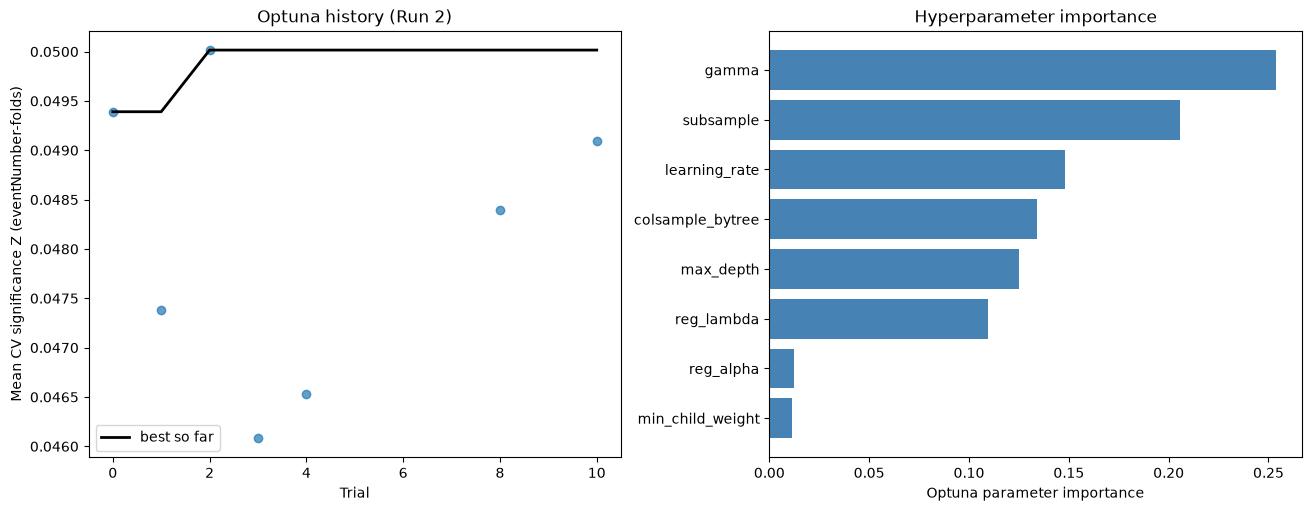

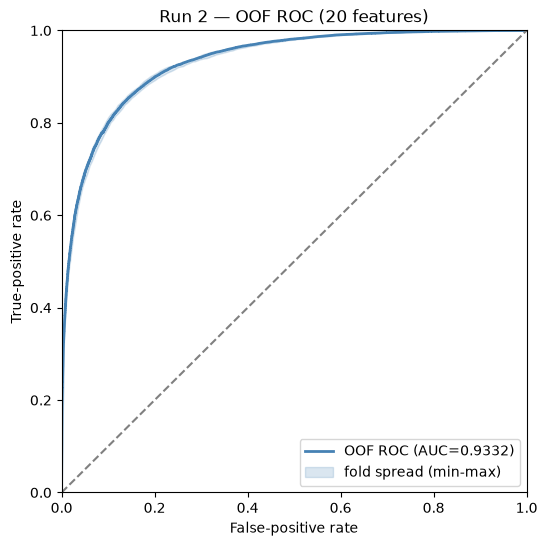

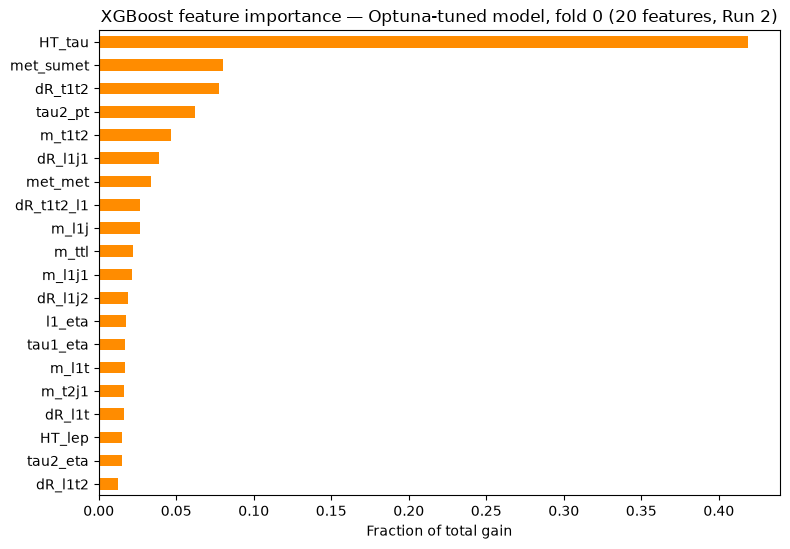

In [30]:
# ---- Final 5-fold OOF models + diagnostics (Run 2) --------------------------
# Hyperparameters frozen from the Optuna study above - NOT re-tuned per fold.
best_params_r2 = params_from_study(study_r2)
oof_df_r2, models_r2 = run_kfold_xgb(
    data_r2, OPTUNA_FEATURES_R2, best_params_r2, target_yields_r2,
    cell_cols=(), n_folds=N_FOLDS, label="Run2",
)

plot_optuna_diagnostics(study_r2, title_suffix="(Run 2)")
oof_auc_r2 = plot_oof_roc(oof_df_r2, title=f"Run 2 — OOF ROC ({len(OPTUNA_FEATURES_R2)} features)")

final_imp_r2 = get_importance(models_r2[0], OPTUNA_FEATURES_R2)
plot_importance_bar(
    final_imp_r2, top_n=len(OPTUNA_FEATURES_R2),
    title=f"XGBoost feature importance — Optuna-tuned model, fold 0 ({len(OPTUNA_FEATURES_R2)} features, Run 2)",
    color="darkorange",
)


In [31]:
# ---- Persist the Run-2 fold models + feature list + hyperparams + OOF -------
# Replaces the old single final_model_run2.json / splits/{train,val}.root -
# there is no single final model anymore (see run_kfold_xgb docstring). Used
# by Section 6 (Run2 vs Run3 domain-shift check) and ModelComparison.ipynb.
save_track_artifacts(models_r2, OPTUNA_FEATURES_R2, best_params_r2, oof_df_r2, BASE_DIR_R2, "run2")


Saved 5 fold models + feature list + hyperparams + OOF scores -> PPSSP_2026/1l2tau/run2/ (track=run2)


## 4. Run 3 — Solo Track

Identical procedure to Section 3, independently on **Run 3 only** (separate
feature-discovery pass too, in case branches differ slightly between
campaigns).


In [32]:
# ---- Load & clean (Run 3) ---------------------------------------------------
features_r3 = discover_common_features([BASE_DIR_R3])
data_r3 = load_run_data(BASE_DIR_R3, run_label=3, features=features_r3)
data_r3, features_r3 = clean_data(data_r3, features_r3)
data_r3 = assign_folds(data_r3, n_folds=N_FOLDS)
print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}):")
print(data_r3["fold"].value_counts().sort_index())
data_r3.head()


80 candidate features (common to all 10 processes x 1 run(s) = 10 files, leakage-free)


Run 3 signal_ggF  :   191580 events after preselection
Run 3 signal_VBF  :    13470 events after preselection
Run 3 Diboson     :   628676 events after preselection
Run 3 Zjets       :   157073 events after preselection
Run 3 Wjets       :    39061 events after preselection
Run 3 ttbar       :    40832 events after preselection
Run 3 tops        :   161226 events after preselection
Run 3 SingleH     :    38425 events after preselection
Run 3 Vgamma      :    14295 events after preselection
Run 3 VVV         :    40254 events after preselection
Dropped 16 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_decayMode', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_decayMode']

64 final features
Total: 1324892 events | signal = 205050 | background = 1119842
Yield (w_phys): signal = 2.08 | background = 19366.92

Fold sizes (fold =

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_phi,tau2_pt,weight,weights,eventNumber,w_phys,label,process,run,fold
0,"295,410.938","225,582.062","139,812.219","27,723.984","97,552.883","58,045.852","74,214.664","66,489.398","56,902.617",3.118,...,-1.305,"23,250.283",0.001,0.040,108767,0.000,1,signal_ggF,3,2
1,"505,036.750","313,843.375","113,722.625","144,957.328","336,150.688","55,163.426","181,061.453","219,900.609","52,511.066",0.698,...,-1.316,"24,946.242",0.001,0.042,296823,0.000,1,signal_ggF,3,3
2,"317,003.156","279,036.906","194,843.141","20,118.156","58,084.398","64,075.617","46,115.941","85,579.805","29,741.354",2.051,...,-0.555,"26,483.121",0.001,0.049,41247,0.000,1,signal_ggF,3,2
3,"505,021.500","447,686.375","232,611.266","33,814.699","91,149.812","181,260.422","131,265.047","131,265.047","88,135.117",0.449,...,-2.463,"50,765.574",0.001,0.033,182723,0.000,1,signal_ggF,3,3
4,"663,091.812","590,826.000","457,783.594","91,843.344","164,109.219","41,199.023","113,508.242","182,620.422","21,455.129",3.567,...,2.298,"20,445.324",0.001,0.024,121221,0.000,1,signal_ggF,3,1


In [33]:
# ---- Yields / S over B (Run 3) ----------------------------------------------
yields_r3 = compute_yields(data_r3, BASE_DIR_R3)


   process    N_mc  yield_skim  N_presel      yield  pct_of_bkg  frac_neg
     Wjets   90957  79,013.789     39061 10,898.551      56.274     0.148
     Zjets  339840  31,376.286    157073  4,803.814      24.804     0.148
     ttbar  371546  15,719.117     40832  1,961.856      10.130     0.003
   Diboson 1305959   3,138.175    628676    923.780       4.770     0.061
    Vgamma   36859   2,422.237     14295    433.656       2.239     0.079
      tops 1364404   1,763.957    161226    239.212       1.235     0.359
   SingleH  267413     507.144     38425    101.232       0.523     0.003
       VVV  122940      13.324     40254      4.821       0.025     0.011
signal_ggF  383574       3.831    191580      2.005         NaN     0.062
signal_VBF   30333       0.170     13470      0.076         NaN     0.001

Total background (presel): 19,366.920
Total signal     (presel): 2.081
S/B       = 1.07e-04
S/sqrt(B) = 0.0150


Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3WeightBalance.png


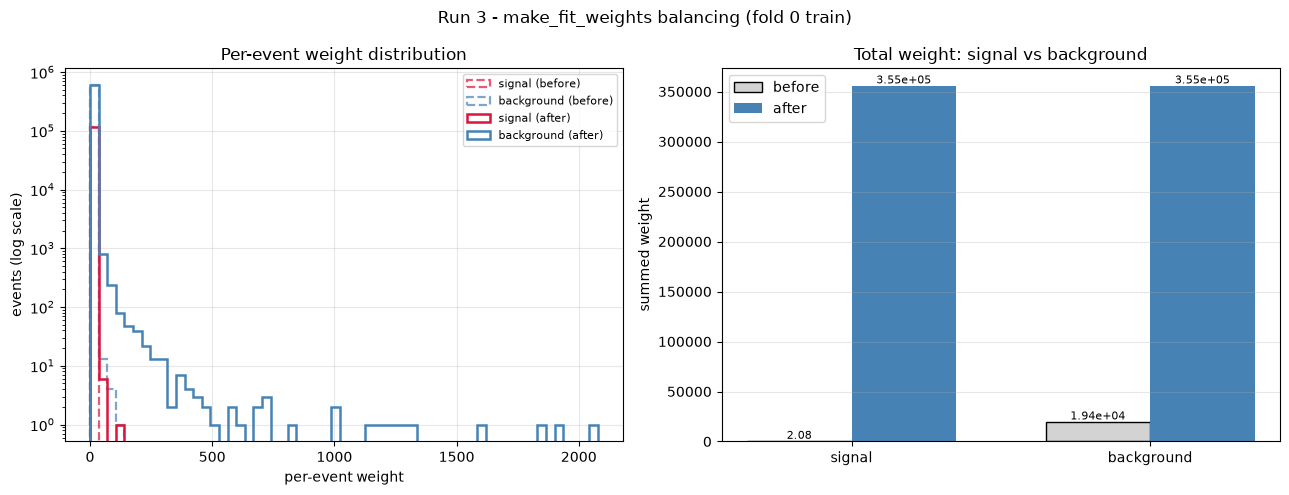

N_eff (training sample, positive-only, post yield-rescale) by label - fold 0:
label
0    2,802.791
1   52,259.467
Name: n_eff, dtype: float64

N_eff (eval sample, signed, FULL fold-0 test partition) by label:
label
0      582.726
1   14,365.649
Name: n_eff, dtype: float64

Dropped 83056 negative-w_phys training rows in this preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).


In [34]:
# ---- Weight-balance diagnostics (Run 3, representative fold 0) --------------
target_yields_r3 = compute_process_yield_targets(data_r3)
fd0_r3 = prepare_fold_data(data_r3, features_r3, target_yields_r3, cell_cols=(), n_folds=N_FOLDS, k=0)

w_before_r3 = fd0_r3["train_df"]["w_phys"].to_numpy()
w_after_r3 = fd0_r3["w_train_fit"]
y_preview_r3 = fd0_r3["train_df"]["label"].to_numpy()

PLOTS_DIR_R3 = BASE_DIR_R3 / "plots"
PLOTS_DIR_R3.mkdir(parents=True, exist_ok=True)
plot_weight_balance(
    y_preview_r3, w_before_r3, w_after_r3,
    title="Run 3 - make_fit_weights balancing (fold 0 train)",
    save_path=PLOTS_DIR_R3 / "Run3WeightBalance.png",
)

print("N_eff (training sample, positive-only, post yield-rescale) by label - fold 0:")
print(n_eff_table(fd0_r3["train_df"], ["label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by label:")
print(n_eff_table(fd0_r3["test_df"], ["label"]))
print(f"\nDropped {fd0_r3['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


[Run3 baseline (fold-0 preview)] best_iteration=258 | weighted AUC: train=0.9732 val=0.9408

Top 30 features by total gain (Run 3, fold-0 preview):
                 total_gain  gain_frac  weight
HT_tau        1,127,709.375      0.370 423.000
tau1_pt         295,330.250      0.097 285.000
dR_t1t2         136,196.156      0.045 511.000
SumPt_t1t2      135,808.375      0.045 398.000
tau2_pt          98,788.195      0.032 456.000
m_t1t2           83,430.773      0.027 509.000
met_sumet        73,687.227      0.024 379.000
m_l1j            68,480.469      0.022 371.000
HT               63,942.551      0.021 250.000
dR_l1j1          62,295.102      0.020 352.000
met_met          43,581.863      0.014 344.000
m_l1t            38,232.117      0.013 306.000
m_ttl            37,347.840      0.012 310.000
m_l1j1           36,923.258      0.012 284.000
dR_l1j2          32,278.535      0.011 284.000
dR_l1t           31,732.910      0.010 305.000
dR_t1t2_l1       30,664.775      0.010 305.000
HT_all

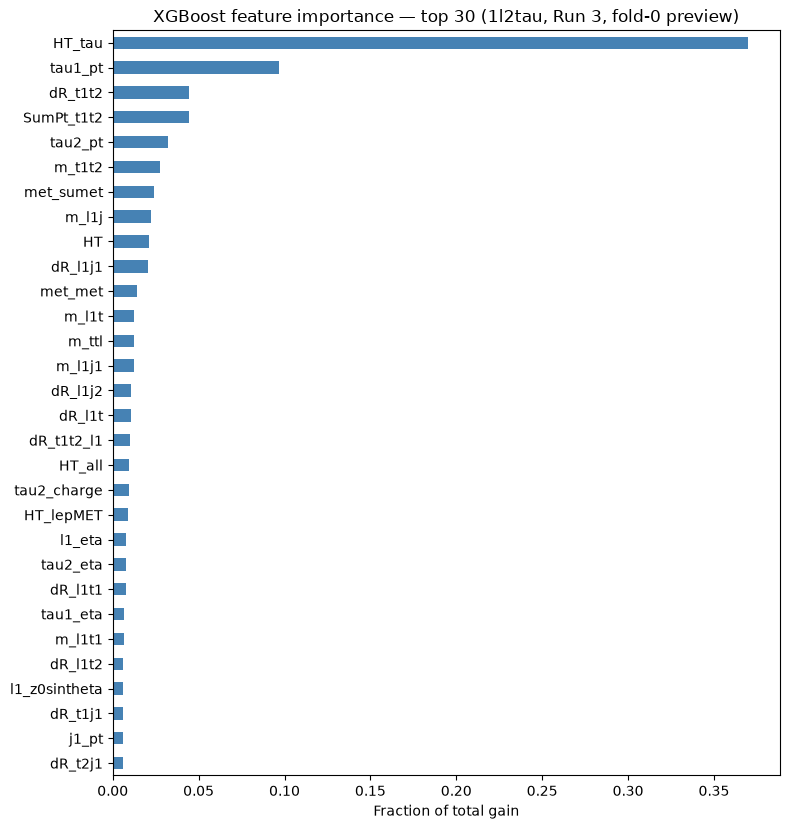

In [35]:
# ---- Baseline XGBoost + feature importance (Run 3, fold-0 preview) ---------
model_r3, auc_train_r3, auc_val_r3 = train_xgb_fold(
    fd0_r3["train_df"][features_r3], fd0_r3["train_df"]["label"], fd0_r3["w_train_fit"],
    fd0_r3["val_df"][features_r3], fd0_r3["val_df"]["label"], np.abs(fd0_r3["val_df"]["w_phys"].to_numpy()),
    label="Run3 baseline (fold-0 preview)",
)

imp_r3 = get_importance(model_r3, features_r3)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Run 3, fold-0 preview):")
print(imp_r3[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_r3['total_gain'] == 0).sum()} / {len(features_r3)}")

plot_importance_bar(imp_r3, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (1l2tau, Run 3, fold-0 preview)")


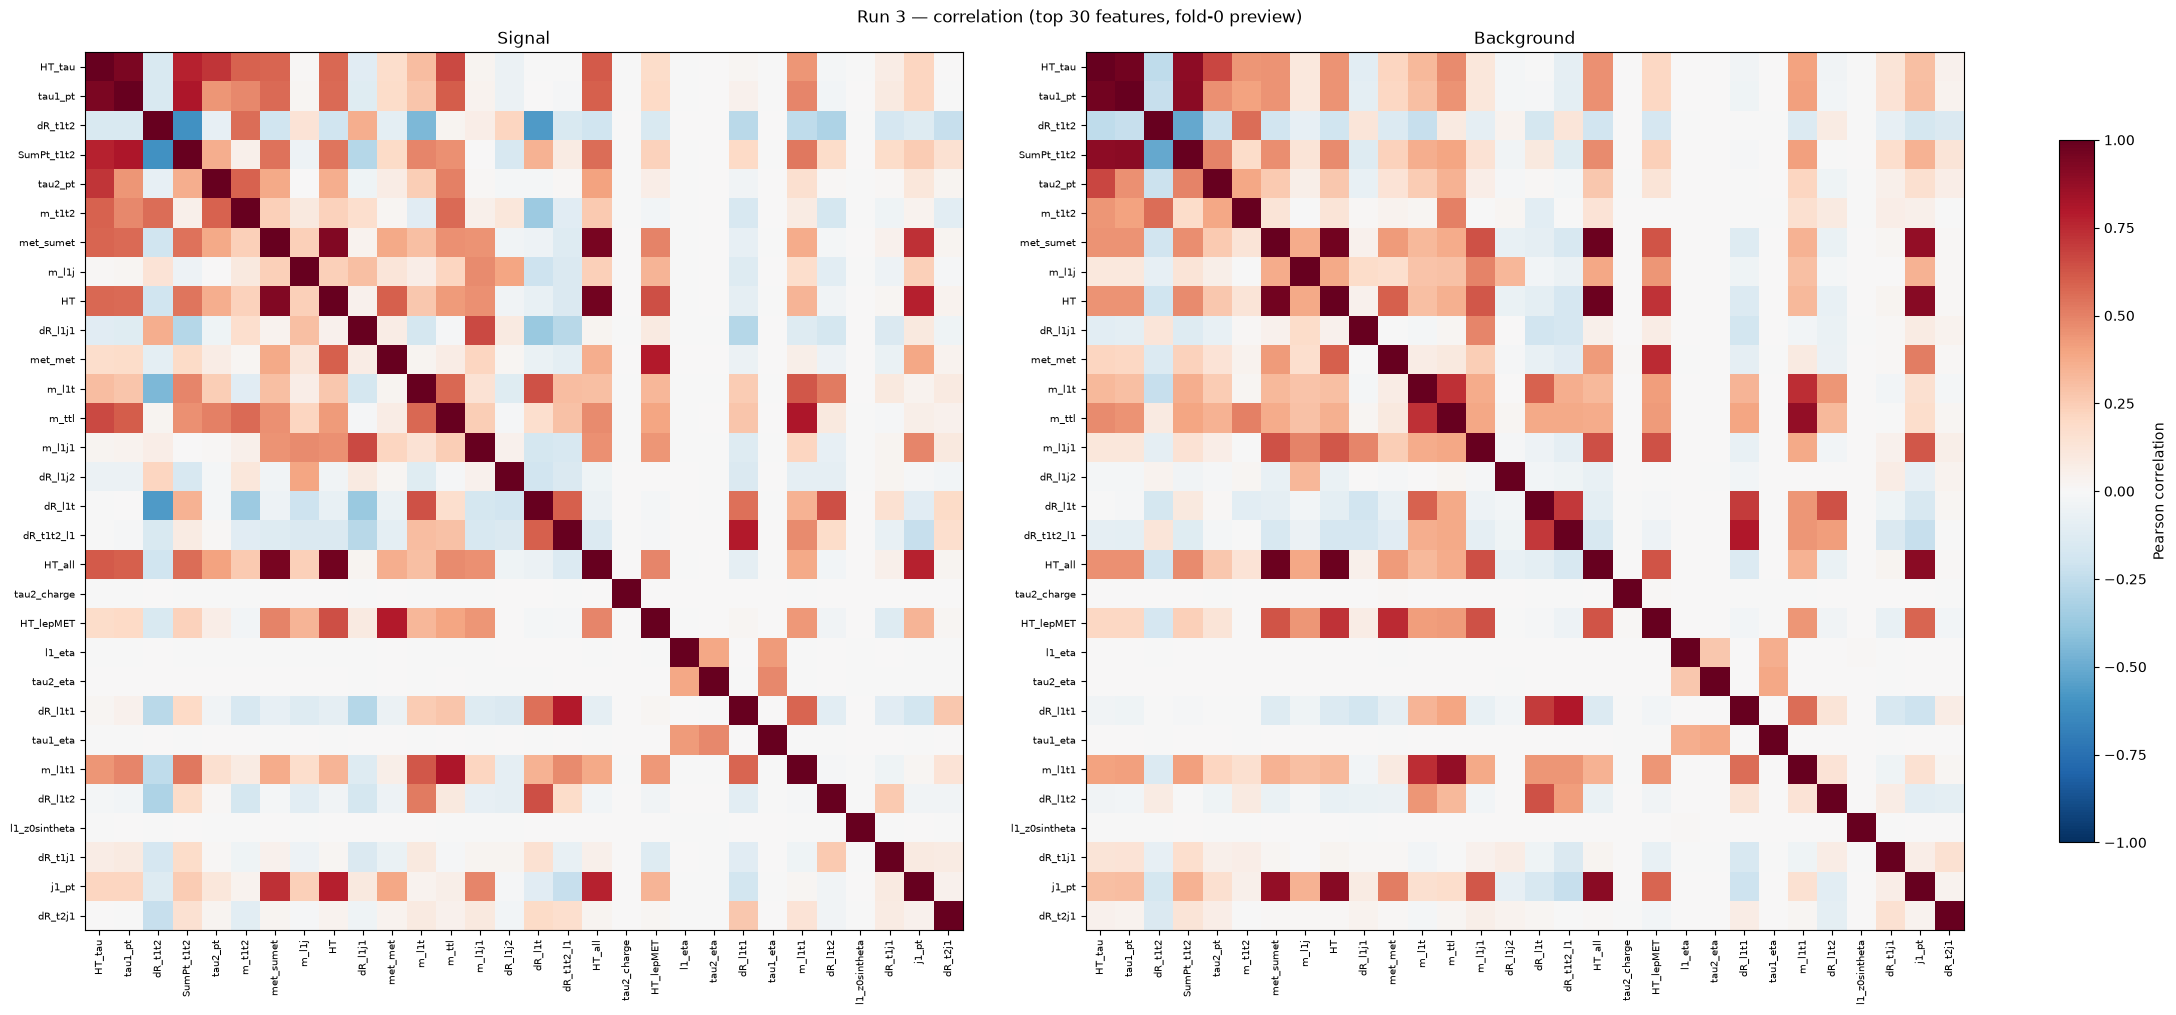

Pairs with |corr| > 0.50 (signal):
HT          HT_all       0.966
met_sumet   HT_all       0.949
HT_tau      tau1_pt      0.945
met_sumet   HT           0.926
tau1_pt     SumPt_t1t2   0.811
m_ttl       m_l1t1       0.810
met_met     HT_lepMET    0.794
dR_t1t2_l1  dR_l1t1      0.793
HT          j1_pt        0.776
HT_all      j1_pt        0.772
HT_tau      SumPt_t1t2   0.768
met_sumet   j1_pt        0.731
HT_tau      tau2_pt      0.711
dR_l1j1     m_l1j1       0.661
HT_tau      m_ttl        0.657
dR_l1t      dR_l1t2      0.648
HT          HT_lepMET    0.641
m_l1t       dR_l1t       0.638
            m_l1t1       0.617
HT_tau      HT_all       0.612
tau1_pt     m_ttl        0.605
dR_t1t2     SumPt_t1t2   0.603
dR_l1t      dR_t1t2_l1   0.597
tau1_pt     HT_all       0.595
HT          met_met      0.594
HT_tau      m_t1t2       0.593
tau2_pt     m_t1t2       0.590
dR_l1t1     m_l1t1       0.583
HT_tau      met_sumet    0.582
            HT           0.578
m_l1t       m_ttl        0.572
tau1

In [36]:
# ---- Correlation of the top features (Run 3, fold-0 preview train set) -----
top_feats_r3 = imp_r3.index[:TOP_N_IMPORTANCE].tolist()
corrs_r3 = grouped_correlations(fd0_r3["train_df"], top_feats_r3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [corrs_r3[1], corrs_r3[0]], ["Signal", "Background"], top_feats_r3,
    suptitle=f"Run 3 — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_r3[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_r3[0]).to_string())


In [37]:
# ---- Correlation-based pruning to a decorrelated top-20 (Run 3) ------------
corr_max_r3 = corrs_r3[1].abs().combine(corrs_r3[0].abs(), np.maximum)
PRUNED_FEATURES_R3, dropped_r3 = prune_correlated(top_feats_r3, corr_max_r3, CORR_THRESH, N_KEEP)


Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. dR_t1t2
   3. tau2_pt
   4. m_t1t2
   5. met_sumet
   6. m_l1j
   7. dR_l1j1
   8. met_met
   9. m_l1t
  10. m_ttl
  11. m_l1j1
  12. dR_l1j2
  13. dR_l1t
  14. dR_t1t2_l1
  15. tau2_charge
  16. l1_eta
  17. tau2_eta
  18. tau1_eta
  19. dR_l1t2
  20. l1_z0sintheta

Dropped 7 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.967)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.897)
  HT              -> redundant with met_sumet       (|corr| = 0.962)
  HT_all          -> redundant with met_sumet       (|corr| = 0.981)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.794)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.799)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.880)


[Run3 pruned (fold-0 preview)] best_iteration=221 | weighted AUC: train=0.9615 val=0.9303

Comparison (fold-0 preview) — full 64 features: val AUC = 0.9408 | pruned 20 features: val AUC = 0.9303


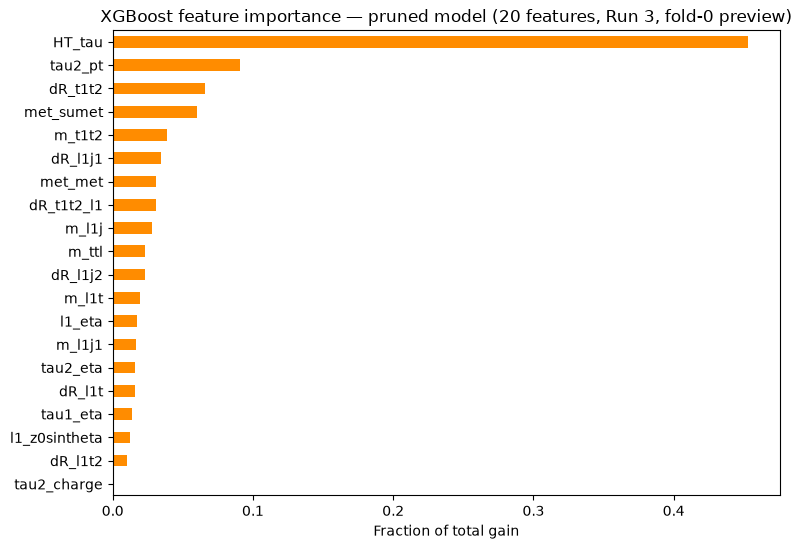

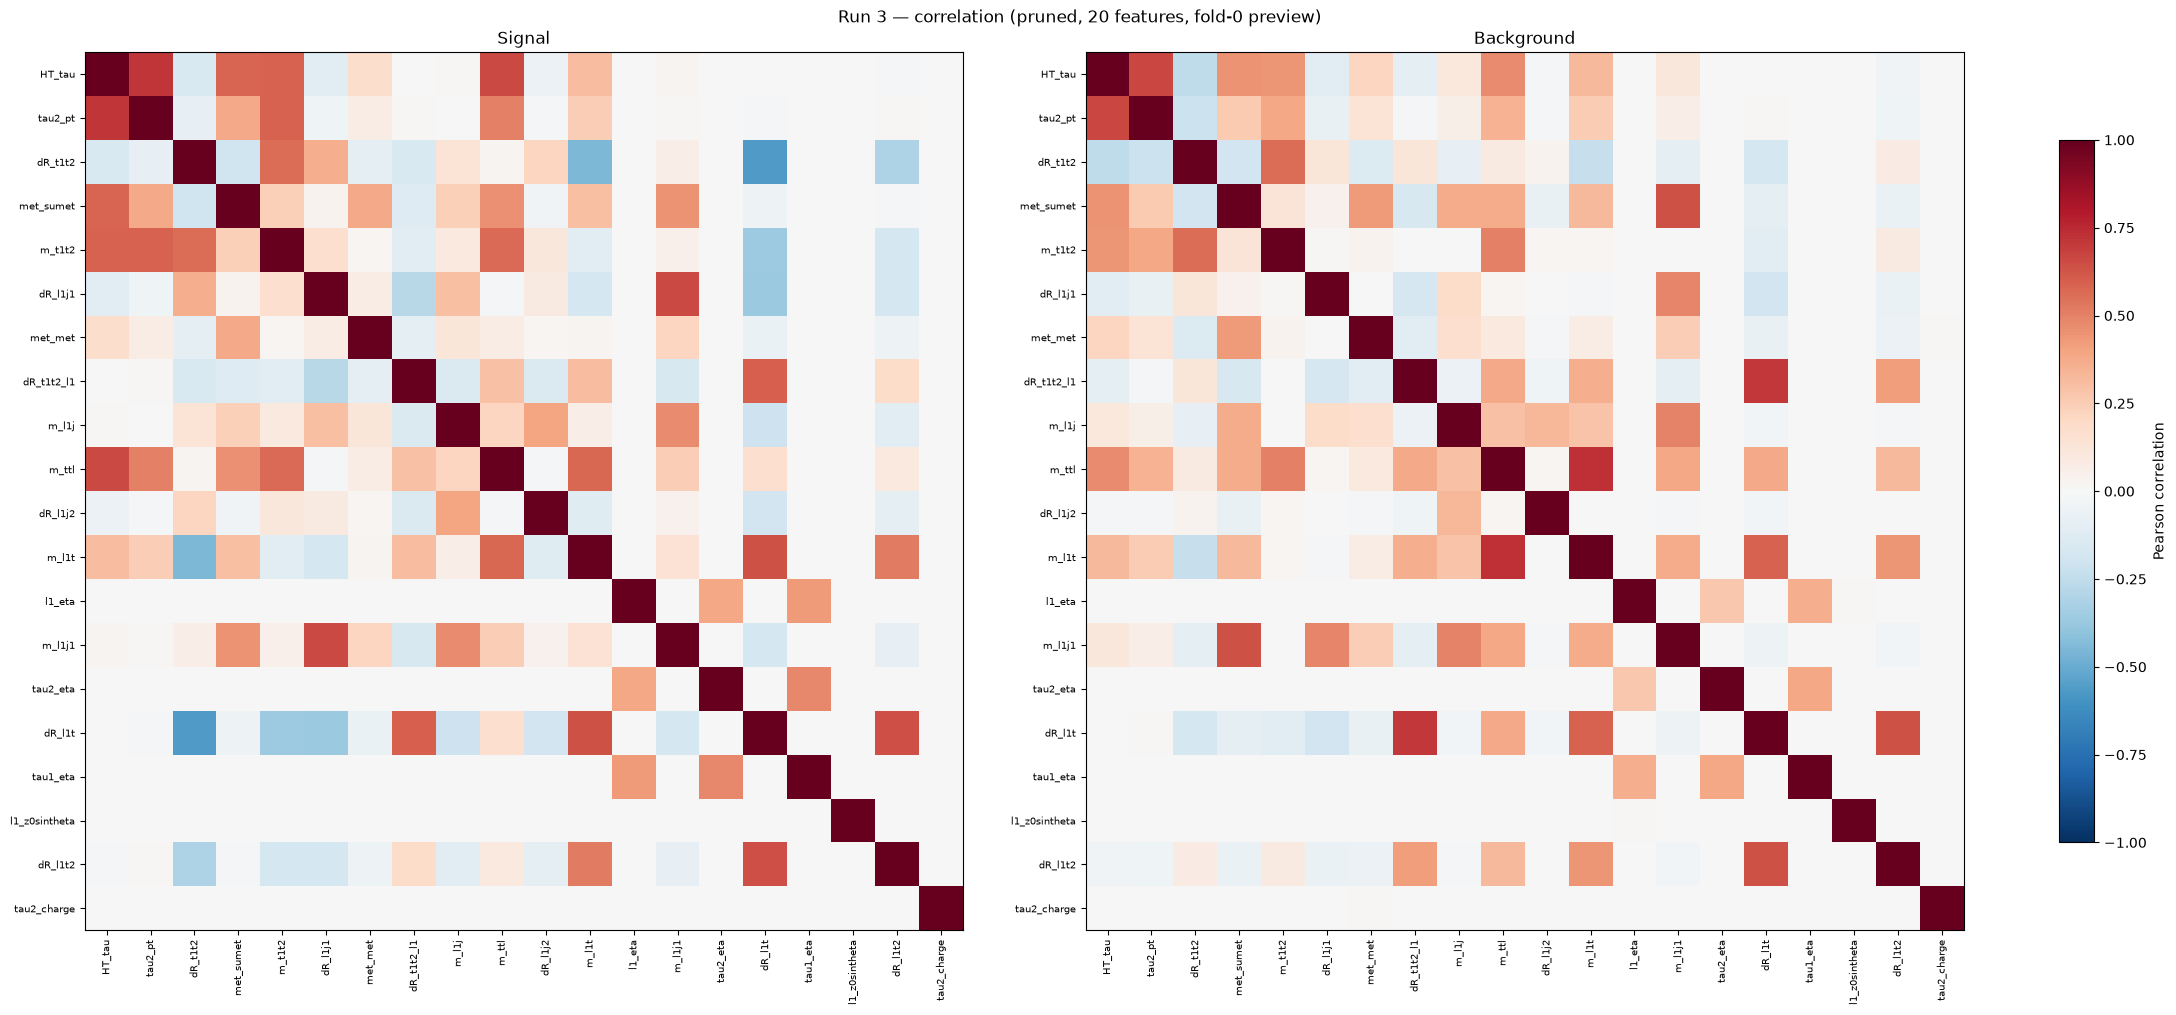

In [38]:
# ---- Retrain on the pruned feature set + re-check correlation (Run 3, fold-0 preview) ------
model_r3_pruned, auc_train_r3_pruned, auc_val_r3_pruned = train_xgb_fold(
    fd0_r3["train_df"][PRUNED_FEATURES_R3], fd0_r3["train_df"]["label"], fd0_r3["w_train_fit"],
    fd0_r3["val_df"][PRUNED_FEATURES_R3], fd0_r3["val_df"]["label"], np.abs(fd0_r3["val_df"]["w_phys"].to_numpy()),
    label="Run3 pruned (fold-0 preview)",
)

imp_r3_pruned = get_importance(model_r3_pruned, PRUNED_FEATURES_R3)
print(f"\nComparison (fold-0 preview) — full {len(features_r3)} features: val AUC = {auc_val_r3:.4f} | "
      f"pruned {len(PRUNED_FEATURES_R3)} features: val AUC = {auc_val_r3_pruned:.4f}")

plot_importance_bar(
    imp_r3_pruned, top_n=len(PRUNED_FEATURES_R3),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_R3)} features, Run 3, fold-0 preview)",
    color="darkorange",
)

pruned_top_feats_r3 = imp_r3_pruned.index.tolist()
pruned_corrs_r3 = grouped_correlations(fd0_r3["train_df"], pruned_top_feats_r3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_r3[1], pruned_corrs_r3[0]], ["Signal", "Background"], pruned_top_feats_r3,
    suptitle=f"Run 3 — correlation (pruned, {len(pruned_top_feats_r3)} features, fold-0 preview)",
)


In [39]:
# ---- Optuna hyperparameter search (Run 3) -----------------------------------
OPTUNA_FEATURES_R3 = PRUNED_FEATURES_R3.copy()

study_r3 = run_optuna_search(
    data_r3, OPTUNA_FEATURES_R3, target_yields_r3, cell_cols=(),
    n_trials=N_OPTUNA_TRIALS, n_folds=N_FOLDS,
    base_n_estimators=800, study_name="xgb_1l2tau_run3",
)


/tmp/ipykernel_108492/844790540.py:106: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[xgb_1l2tau_run3] completed trials: 15
[xgb_1l2tau_run3] best mean CV significance Z (5 eventNumber-folds): 0.05620
[xgb_1l2tau_run3] mean best iteration: 418
[xgb_1l2tau_run3] fold Z's: [0.056424455554316064, 0.06991525513430524, 0.04990549840156616, 0.062126819338378166, 0.04262431303700366]
[xgb_1l2tau_run3] best parameters:
    learning_rate: 0.057161021316138726
    max_depth: 7
    min_child_weight: 2.1839352923182975
    subsample: 0.8056937753654446
    colsample_bytree: 0.836965827544817
    gamma: 0.23225206359998862
    reg_alpha: 0.10907475835157694
    reg_lambda: 0.2885622361859737


[Run3 fold0] best_iteration=314 | weighted AUC: train=0.9681 val=0.9317
[Run3] fold 0: test_fold=0 val_fold=1 | train n=710891 (dropped 83056 neg) | test weighted AUC = 0.9355 | test significance Z = 0.056
[Run3 fold1] best_iteration=338 | weighted AUC: train=0.9693 val=0.9346
[Run3] fold 1: test_fold=1 val_fold=2 | train n=710227 (dropped 83238 neg) | test weighted AUC = 0.9358 | test significance Z = 0.045
[Run3 fold2] best_iteration=414 | weighted AUC: train=0.9727 val=0.9344
[Run3] fold 2: test_fold=2 val_fold=3 | train n=711147 (dropped 83833 neg) | test weighted AUC = 0.9369 | test significance Z = 0.052
[Run3 fold3] best_iteration=262 | weighted AUC: train=0.9638 val=0.9353
[Run3] fold 3: test_fold=3 val_fold=4 | train n=712756 (dropped 83655 neg) | test weighted AUC = 0.9379 | test significance Z = 0.053
[Run3 fold4] best_iteration=212 | weighted AUC: train=0.9611 val=0.9299
[Run3] fold 4: test_fold=4 val_fold=0 | train n=712559 (dropped 83314 neg) | test weighted AUC = 0.9397 

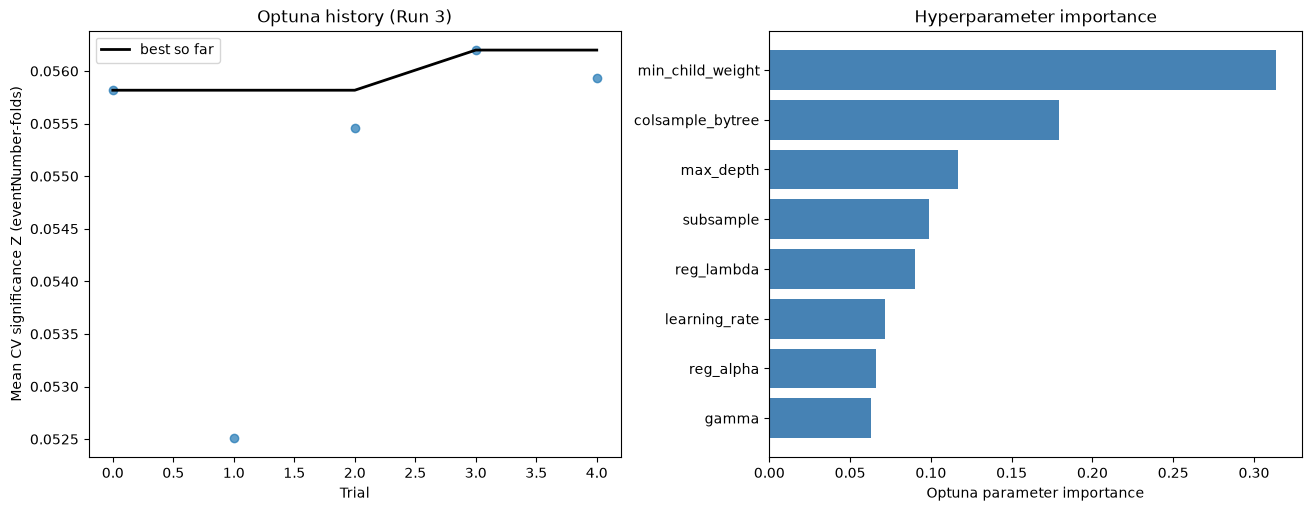

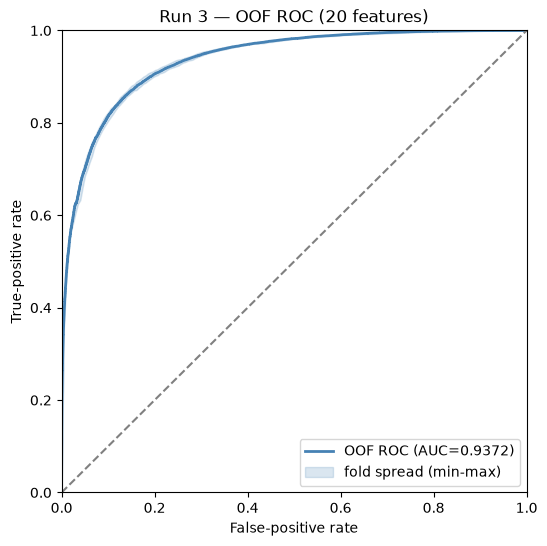

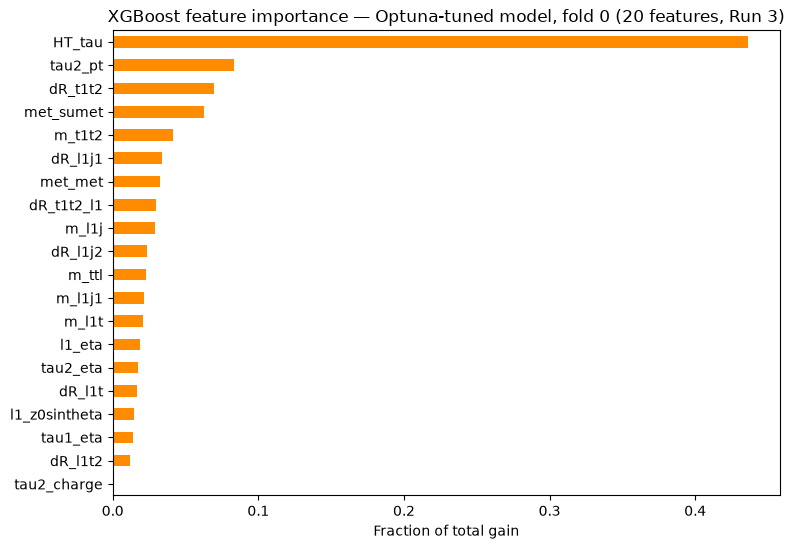

In [40]:
# ---- Final 5-fold OOF models + diagnostics (Run 3) --------------------------
best_params_r3 = params_from_study(study_r3)
oof_df_r3, models_r3 = run_kfold_xgb(
    data_r3, OPTUNA_FEATURES_R3, best_params_r3, target_yields_r3,
    cell_cols=(), n_folds=N_FOLDS, label="Run3",
)

plot_optuna_diagnostics(study_r3, title_suffix="(Run 3)")
oof_auc_r3 = plot_oof_roc(oof_df_r3, title=f"Run 3 — OOF ROC ({len(OPTUNA_FEATURES_R3)} features)")

final_imp_r3 = get_importance(models_r3[0], OPTUNA_FEATURES_R3)
plot_importance_bar(
    final_imp_r3, top_n=len(OPTUNA_FEATURES_R3),
    title=f"XGBoost feature importance — Optuna-tuned model, fold 0 ({len(OPTUNA_FEATURES_R3)} features, Run 3)",
    color="darkorange",
)


In [41]:
# ---- Persist the Run-3 fold models + feature list + hyperparams + OOF -------
save_track_artifacts(models_r3, OPTUNA_FEATURES_R3, best_params_r3, oof_df_r3, BASE_DIR_R3, "run3")


Saved 5 fold models + feature list + hyperparams + OOF scores -> PPSSP_2026/1l2tau/run3/ (track=run3)


## 5. Run 2 + Run 3 — Combined Track

Chain (concatenate) **all** backgrounds and **both** signals from **both**
campaigns into a single training sample, then run the same pipeline. This
checks whether the feature-importance ranking learned on the combined sample
differs from the rankings learned separately in Sections 3/4, and gives the
most statistically powerful (most events) version of the BDT.

The feature list here is rebuilt from branches common to **all 20 files**
(10 processes × 2 runs) - a feature dropped in only one run must be dropped
everywhere once the runs are concatenated. An extra `run` column (2 or 3) is
kept as bookkeeping (never a training feature) so the Run2/Run3 mix in
train/val can be checked, and so the split can be stratified on `label` AND
`run` jointly.


In [42]:
# ---- Load & clean (Combined Run2 + Run3) ------------------------------------
BASE_DIR_COMB = Path("PPSSP_2026/1l2tau/combined")
BASE_DIR_COMB.mkdir(parents=True, exist_ok=True)

features_comb = discover_common_features([BASE_DIR_R2, BASE_DIR_R3])
data_comb = pd.concat(
    [
        load_run_data(BASE_DIR_R2, run_label=2, features=features_comb),
        load_run_data(BASE_DIR_R3, run_label=3, features=features_comb),
    ],
    ignore_index=True,
)
data_comb, features_comb = clean_data(data_comb, features_comb)
data_comb = assign_folds(data_comb, n_folds=N_FOLDS)

# Per-run yield breakdown - confirms both runs contribute comparable
# statistics to the chained sample (no run silently dominating the training).
for run_label in (2, 3):
    sub = data_comb[data_comb.run == run_label]
    print(f"Run {run_label}: signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f} | n_events = {len(sub)}")

print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}):")
print(data_comb["fold"].value_counts().sort_index())
data_comb.head()


80 candidate features (common to all 10 processes x 2 run(s) = 20 files, leakage-free)
Run 2 signal_ggF  :    67075 events after preselection
Run 2 signal_VBF  :    21639 events after preselection
Run 2 Diboson     :   312600 events after preselection
Run 2 Zjets       :   141863 events after preselection
Run 2 Wjets       :    31272 events after preselection
Run 2 ttbar       :     7335 events after preselection
Run 2 tops        :    62238 events after preselection
Run 2 SingleH     :    11124 events after preselection
Run 2 Vgamma      :    21510 events after preselection
Run 2 VVV         :    14028 events after preselection
Run 3 signal_ggF  :   191580 events after preselection
Run 3 signal_VBF  :    13470 events after preselection
Run 3 Diboson     :   628676 events after preselection
Run 3 Zjets       :   157073 events after preselection
Run 3 Wjets       :    39061 events after preselection
Run 3 ttbar       :    40832 events after preselection
Run 3 tops        :   161226 even

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_phi,tau2_pt,weight,weights,eventNumber,w_phys,label,process,run,fold
0,"486,197.281","437,935.438","350,626.938","42,837.090","91,098.922","44,471.410","77,389.633","91,956.719","12,270.166",2.849,...,-3.045,"22,102.740",0.001,-0.028,2978199,-0.000,1,signal_ggF,2,4
1,"233,307.375","192,779.188","92,852.828","31,019.406","71,547.602","68,906.953","35,689.703","32,890.672","20,957.582",2.693,...,1.528,"30,261.955",0.001,0.055,2979398,0.000,1,signal_ggF,2,3
2,"399,998.125","345,424.469","107,697.430","164,906.188","219,479.844","72,820.844","127,177.953","97,451.047","33,988.949",0.400,...,0.594,"33,664.312",0.001,0.030,8078473,0.000,1,signal_ggF,2,3
3,"344,867.656","249,412.125","165,593.328","21,953.850","117,409.383","61,864.949","36,656.707","111,334.617","18,972.348",2.709,...,0.694,"21,605.848",0.001,0.031,7227119,0.000,1,signal_ggF,2,4
4,"326,392.688","270,753.156","128,916.000","71,331.773","126,971.281","70,505.391","129,401.234","129,401.234","55,308.082",2.955,...,-1.724,"31,729.717",0.001,0.032,28478259,0.000,1,signal_ggF,2,4


In [43]:
# ---- Yields / S over B (Combined) -------------------------------------------
# The combined sample is exactly Run2 + Run3 (same processes, same
# preselection), so its yields are simply the per-process sum of the two
# per-run tables already computed in Sections 3/4 - no need to re-read the
# ROOT files a third time.
yields_comb = (
    yields_r2.set_index("process")[["yield", "N_presel"]]
    .add(yields_r3.set_index("process")[["yield", "N_presel"]], fill_value=0)
    .reset_index()
)
is_signal_map = {proc: (label == 1) for proc, (_, label) in FILES.items()}
yields_comb["is_signal"] = yields_comb["process"].map(is_signal_map)

bkg_total_comb = yields_comb.loc[~yields_comb.is_signal, "yield"].sum()
sig_total_comb = yields_comb.loc[yields_comb.is_signal, "yield"].sum()
yields_comb["pct_of_bkg"] = np.where(~yields_comb.is_signal, 100 * yields_comb["yield"] / bkg_total_comb, np.nan)
yields_comb = yields_comb.sort_values(["is_signal", "yield"], ascending=[True, False])

print(yields_comb.to_string(index=False))
print(f"\nTotal background (presel, Run2+Run3): {bkg_total_comb:,.3f}")
print(f"Total signal     (presel, Run2+Run3): {sig_total_comb:,.3f}")
print(f"S/B       = {sig_total_comb/bkg_total_comb:.2e}")
print(f"S/sqrt(B) = {sig_total_comb/np.sqrt(bkg_total_comb):.4f}")


   process      yield  N_presel  is_signal  pct_of_bkg
     Wjets 16,597.206     70333      False      53.827
     Zjets  8,385.972    298936      False      27.197
     ttbar  2,956.109     48167      False       9.587
   Diboson  1,654.147    941276      False       5.365
    Vgamma    710.144     35805      False       2.303
      tops    360.126    223464      False       1.168
   SingleH    161.085     49549      False       0.522
       VVV      9.419     54282      False       0.031
signal_ggF      3.762    258655       True         NaN
signal_VBF      0.143     35109       True         NaN

Total background (presel, Run2+Run3): 30,834.208
Total signal     (presel, Run2+Run3): 3.905
S/B       = 1.27e-04
S/sqrt(B) = 0.0222


Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedWeightBalance.png


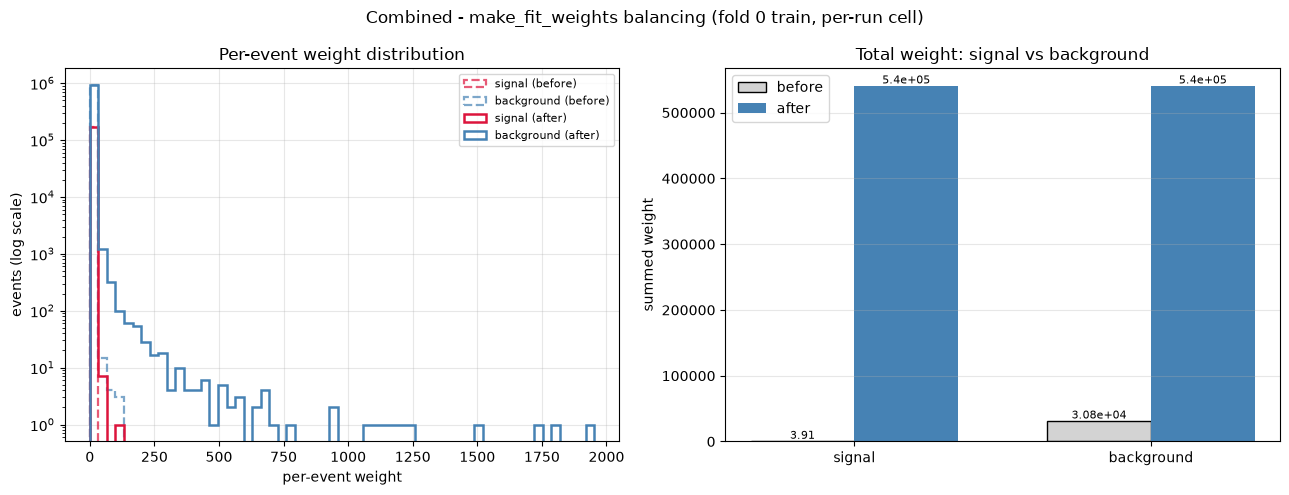

N_eff (training sample, positive-only, post yield-rescale) by run x label - fold 0:
run  label
2    0        4,668.867
     1       27,496.444
3    0        2,828.895
     1       52,250.954
Name: n_eff, dtype: float64

N_eff (eval sample, signed, FULL fold-0 test partition) by run x label:
run  label
2    0          956.475
     1        7,398.000
3    0          582.726
     1       14,365.649
Name: n_eff, dtype: float64

Dropped 127869 negative-w_phys training rows in this preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).


In [44]:
# ---- Weight-balance diagnostics (Combined, representative fold 0) ----------
# Stratifying by "run" here (cell_cols=("run",)) balances signal vs
# background WITHIN each run separately before the global mean-normalization
# - stops whichever run has the most MC events from dominating the pooled
# loss (see make_fit_weights docstring).
target_yields_comb = compute_process_yield_targets(data_comb)
fd0_comb = prepare_fold_data(data_comb, features_comb, target_yields_comb, cell_cols=("run",), n_folds=N_FOLDS, k=0)

w_before_comb = fd0_comb["train_df"]["w_phys"].to_numpy()
w_after_comb = fd0_comb["w_train_fit"]
y_preview_comb = fd0_comb["train_df"]["label"].to_numpy()

PLOTS_DIR_COMB = BASE_DIR_COMB / "plots"
PLOTS_DIR_COMB.mkdir(parents=True, exist_ok=True)
plot_weight_balance(
    y_preview_comb, w_before_comb, w_after_comb,
    title="Combined - make_fit_weights balancing (fold 0 train, per-run cell)",
    save_path=PLOTS_DIR_COMB / "CombinedWeightBalance.png",
)

print("N_eff (training sample, positive-only, post yield-rescale) by run x label - fold 0:")
print(n_eff_table(fd0_comb["train_df"], ["run", "label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by run x label:")
print(n_eff_table(fd0_comb["test_df"], ["run", "label"]))
print(f"\nDropped {fd0_comb['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


[Combined baseline (fold-0 preview)] best_iteration=390 | weighted AUC: train=0.9712 val=0.9408

Top 30 features by total gain (Combined Run2+Run3, fold-0 preview):
               total_gain  gain_frac  weight
HT_tau      1,630,433.625      0.360 533.000
tau1_pt       427,880.781      0.094 426.000
dR_t1t2       234,722.375      0.052 766.000
SumPt_t1t2    198,046.219      0.044 582.000
tau2_pt       136,682.844      0.030 581.000
m_t1t2        128,872.891      0.028 764.000
met_sumet     119,365.562      0.026 548.000
dR_l1j1       104,089.734      0.023 515.000
HT            100,243.734      0.022 388.000
m_l1j          97,145.141      0.021 504.000
met_met        71,354.977      0.016 567.000
m_l1j1         55,679.352      0.012 469.000
m_ttl          54,034.789      0.012 419.000
m_l1t          51,461.602      0.011 479.000
dR_t1t2_l1     48,770.805      0.011 474.000
dR_l1t         46,657.473      0.010 489.000
HT_all         45,326.250      0.010 348.000
dR_l1j2        41,102.512

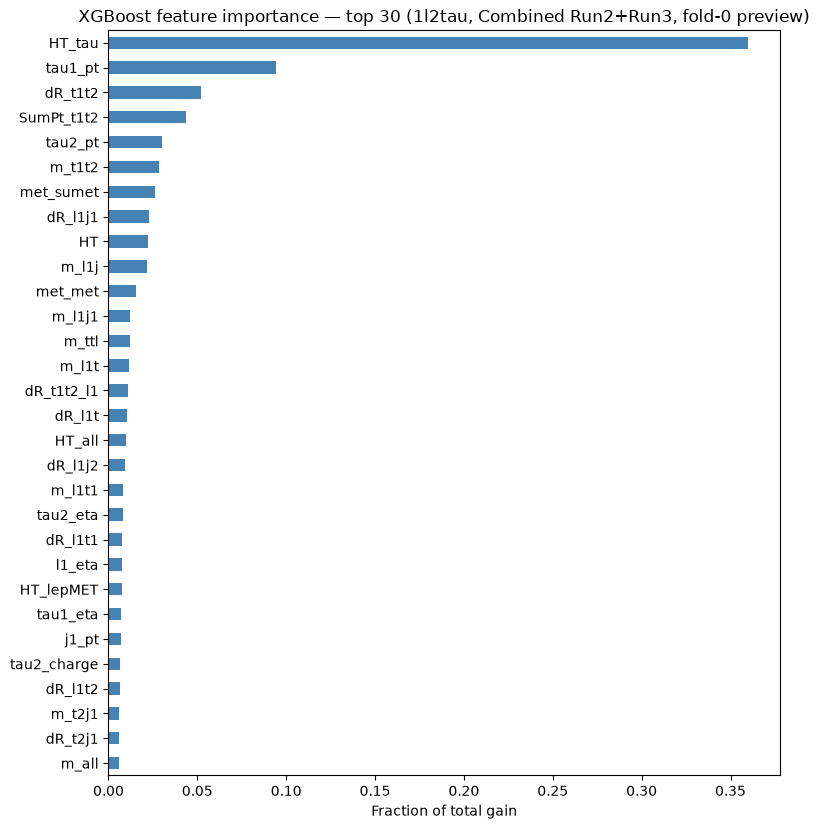

In [45]:
# ---- Baseline XGBoost + feature importance (Combined, fold-0 preview) ------
model_comb, auc_train_comb, auc_val_comb = train_xgb_fold(
    fd0_comb["train_df"][features_comb], fd0_comb["train_df"]["label"], fd0_comb["w_train_fit"],
    fd0_comb["val_df"][features_comb], fd0_comb["val_df"]["label"], np.abs(fd0_comb["val_df"]["w_phys"].to_numpy()),
    label="Combined baseline (fold-0 preview)",
)

imp_comb = get_importance(model_comb, features_comb)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Combined Run2+Run3, fold-0 preview):")
print(imp_comb[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_comb['total_gain'] == 0).sum()} / {len(features_comb)}")

plot_importance_bar(imp_comb, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (1l2tau, Combined Run2+Run3, fold-0 preview)")


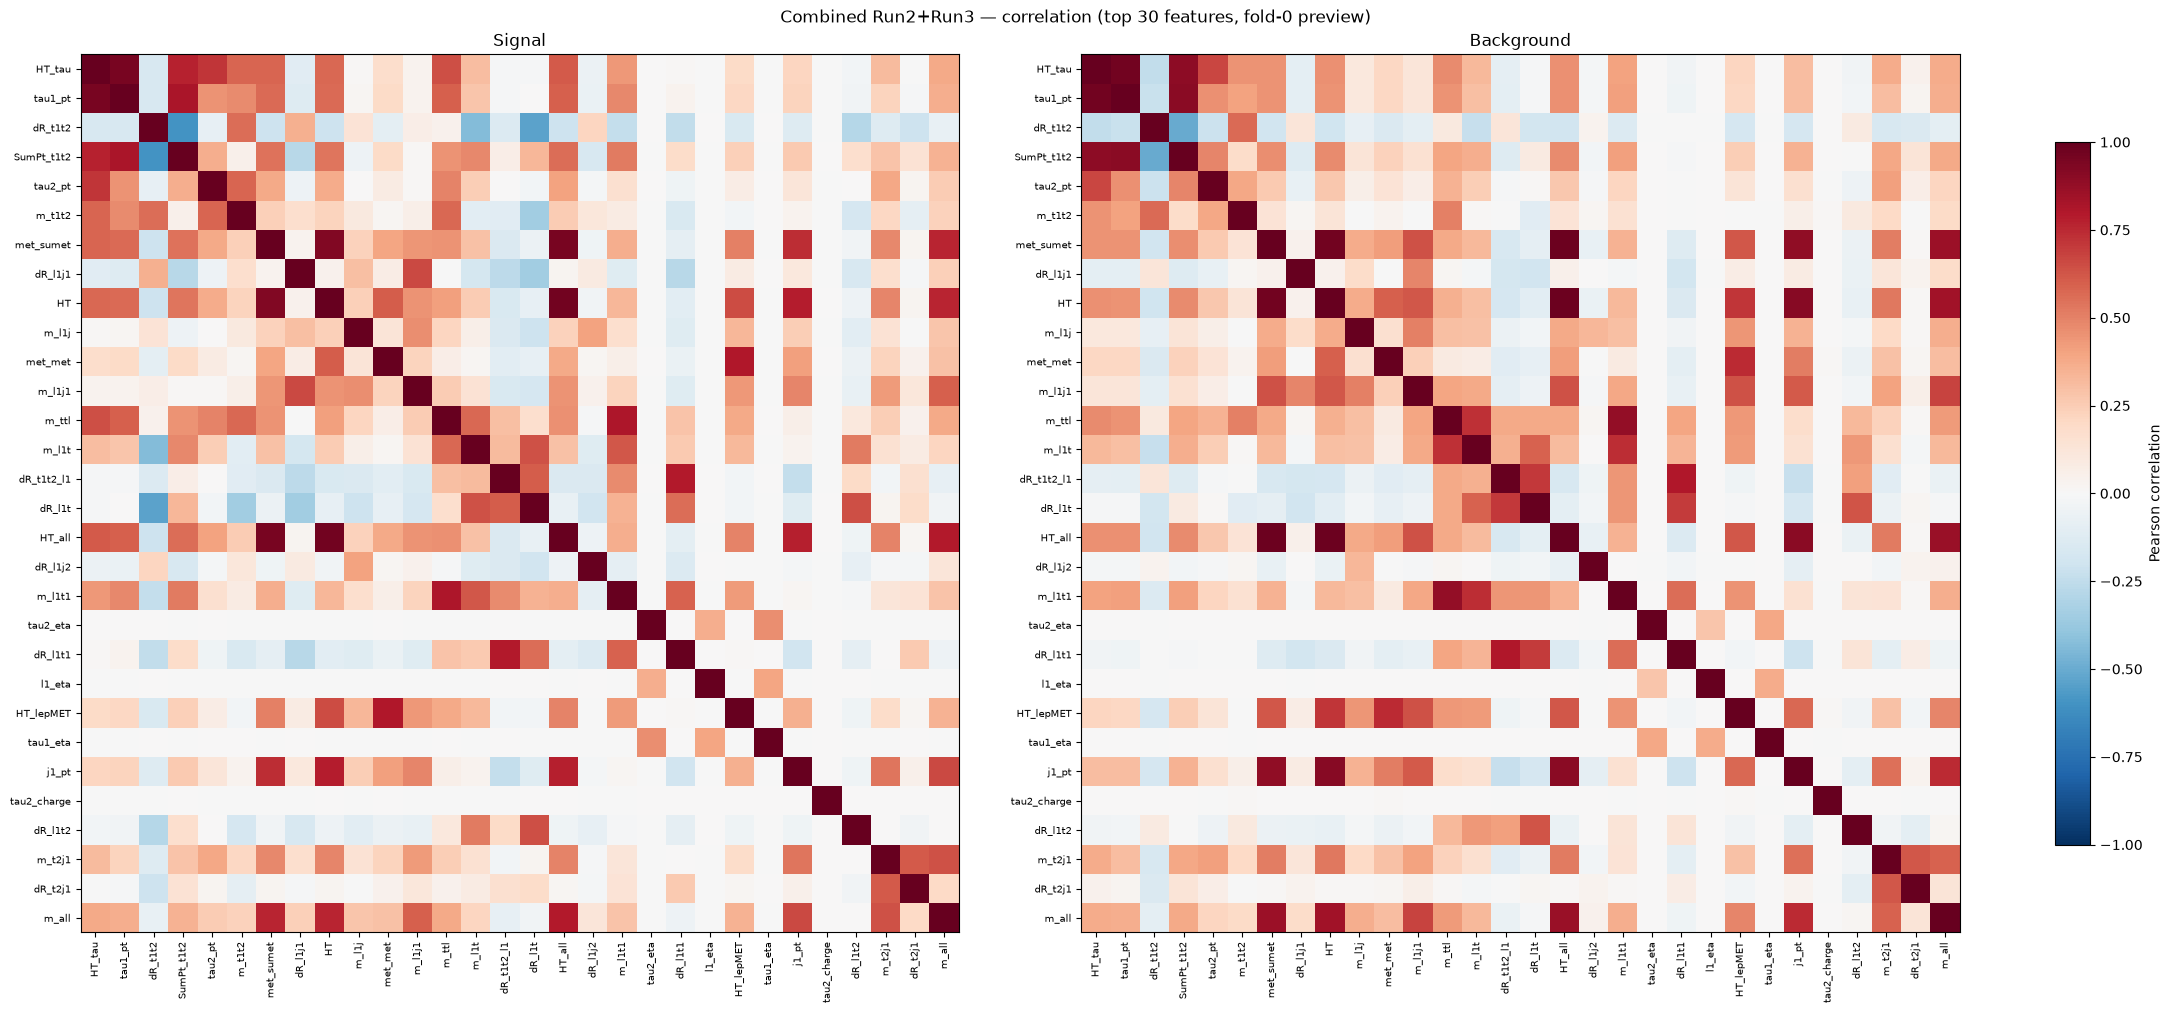

Pairs with |corr| > 0.50 (signal):
HT          HT_all       0.967
met_sumet   HT_all       0.950
HT_tau      tau1_pt      0.945
met_sumet   HT           0.928
tau1_pt     SumPt_t1t2   0.813
m_ttl       m_l1t1       0.808
met_met     HT_lepMET    0.800
HT_all      m_all        0.793
dR_t1t2_l1  dR_l1t1      0.793
HT          j1_pt        0.784
HT_all      j1_pt        0.779
HT_tau      SumPt_t1t2   0.769
HT          m_all        0.764
met_sumet   m_all        0.761
            j1_pt        0.740
HT_tau      tau2_pt      0.713
dR_l1j1     m_l1j1       0.660
j1_pt       m_all        0.659
HT          HT_lepMET    0.649
dR_l1t      dR_l1t2      0.647
HT_tau      m_ttl        0.647
m_l1t       dR_l1t       0.636
m_t2j1      m_all        0.633
m_l1t       m_l1t1       0.619
m_t2j1      dR_t2j1      0.616
HT_tau      HT_all       0.611
HT          met_met      0.604
dR_t1t2_l1  dR_l1t       0.603
dR_t1t2     SumPt_t1t2   0.599
m_l1j1      m_all        0.597
tau1_pt     m_ttl        0.595
    

In [46]:
# ---- Correlation of the top features + pruning (Combined, fold-0 preview) --
top_feats_comb = imp_comb.index[:TOP_N_IMPORTANCE].tolist()
corrs_comb = grouped_correlations(fd0_comb["train_df"], top_feats_comb, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [corrs_comb[1], corrs_comb[0]], ["Signal", "Background"], top_feats_comb,
    suptitle=f"Combined Run2+Run3 — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_comb[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_comb[0]).to_string())

corr_max_comb = corrs_comb[1].abs().combine(corrs_comb[0].abs(), np.maximum)
PRUNED_FEATURES_COMB, dropped_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, N_KEEP)


[Combined pruned (fold-0 preview)] best_iteration=258 | weighted AUC: train=0.9548 val=0.9303

Comparison (fold-0 preview) — full 64 features: val AUC = 0.9408 | pruned 20 features: val AUC = 0.9303


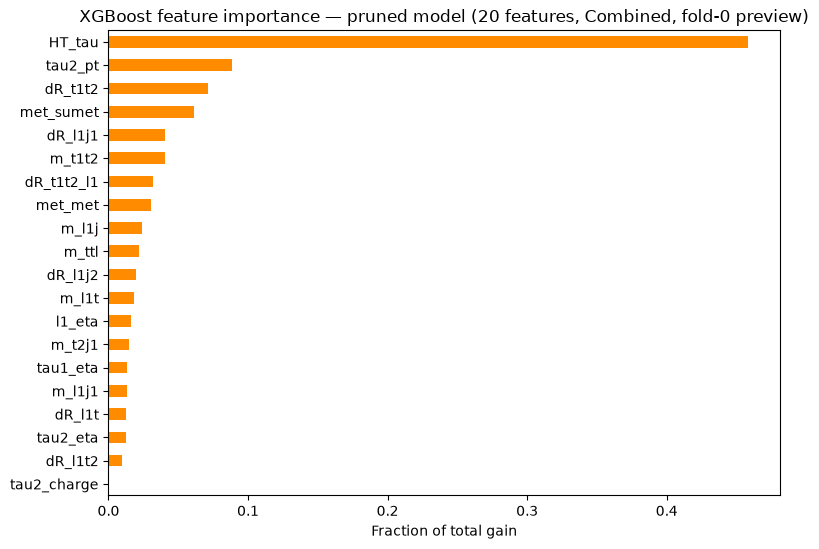

In [47]:
# ---- Retrain on the pruned feature set + re-check correlation (Combined, fold-0 preview) ---
model_comb_pruned, auc_train_comb_pruned, auc_val_comb_pruned = train_xgb_fold(
    fd0_comb["train_df"][PRUNED_FEATURES_COMB], fd0_comb["train_df"]["label"], fd0_comb["w_train_fit"],
    fd0_comb["val_df"][PRUNED_FEATURES_COMB], fd0_comb["val_df"]["label"], np.abs(fd0_comb["val_df"]["w_phys"].to_numpy()),
    label="Combined pruned (fold-0 preview)",
)

imp_comb_pruned = get_importance(model_comb_pruned, PRUNED_FEATURES_COMB)
print(f"\nComparison (fold-0 preview) — full {len(features_comb)} features: val AUC = {auc_val_comb:.4f} | "
      f"pruned {len(PRUNED_FEATURES_COMB)} features: val AUC = {auc_val_comb_pruned:.4f}")

plot_importance_bar(
    imp_comb_pruned, top_n=len(PRUNED_FEATURES_COMB),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_COMB)} features, Combined, fold-0 preview)",
    color="darkorange",
)


### Top-15 further cut

Take the top 15 features from the pruned model's own ranking and retrain once
more, to see how much validation AUC is lost going from 20 → 15 features.


In [48]:
# ---- Retrain using only the top 15 features (Combined, fold-0 preview) -----
TOP_15 = 15
TOP15_FEATURES_COMB = imp_comb_pruned.index[:TOP_15].tolist()
print(f"Top {TOP_15} features kept (from the 20-feature pruned model's own ranking):")
for i, feat in enumerate(TOP15_FEATURES_COMB, 1):
    print(f"  {i:2d}. {feat}")

model_comb_top15, auc_train_comb_top15, auc_val_comb_top15 = train_xgb_fold(
    fd0_comb["train_df"][TOP15_FEATURES_COMB], fd0_comb["train_df"]["label"], fd0_comb["w_train_fit"],
    fd0_comb["val_df"][TOP15_FEATURES_COMB], fd0_comb["val_df"]["label"], np.abs(fd0_comb["val_df"]["w_phys"].to_numpy()),
    label="Combined top-15 (fold-0 preview)",
)

print(f"\nWeighted AUC (top {TOP_15} features, fold-0 preview):  val = {auc_val_comb_top15:.4f}")
print(f"Weighted AUC (pruned {len(PRUNED_FEATURES_COMB)} features, fold-0 preview): val = {auc_val_comb_pruned:.4f}")
print(f"Weighted AUC (full {len(features_comb)} features, fold-0 preview):    val = {auc_val_comb:.4f}")


Top 15 features kept (from the 20-feature pruned model's own ranking):
   1. HT_tau
   2. tau2_pt
   3. dR_t1t2
   4. met_sumet
   5. dR_l1j1
   6. m_t1t2
   7. dR_t1t2_l1
   8. met_met
   9. m_l1j
  10. m_ttl
  11. dR_l1j2
  12. m_l1t
  13. l1_eta
  14. m_t2j1
  15. tau1_eta


[Combined top-15 (fold-0 preview)] best_iteration=245 | weighted AUC: train=0.9521 val=0.9291

Weighted AUC (top 15 features, fold-0 preview):  val = 0.9291
Weighted AUC (pruned 20 features, fold-0 preview): val = 0.9303
Weighted AUC (full 64 features, fold-0 preview):    val = 0.9408


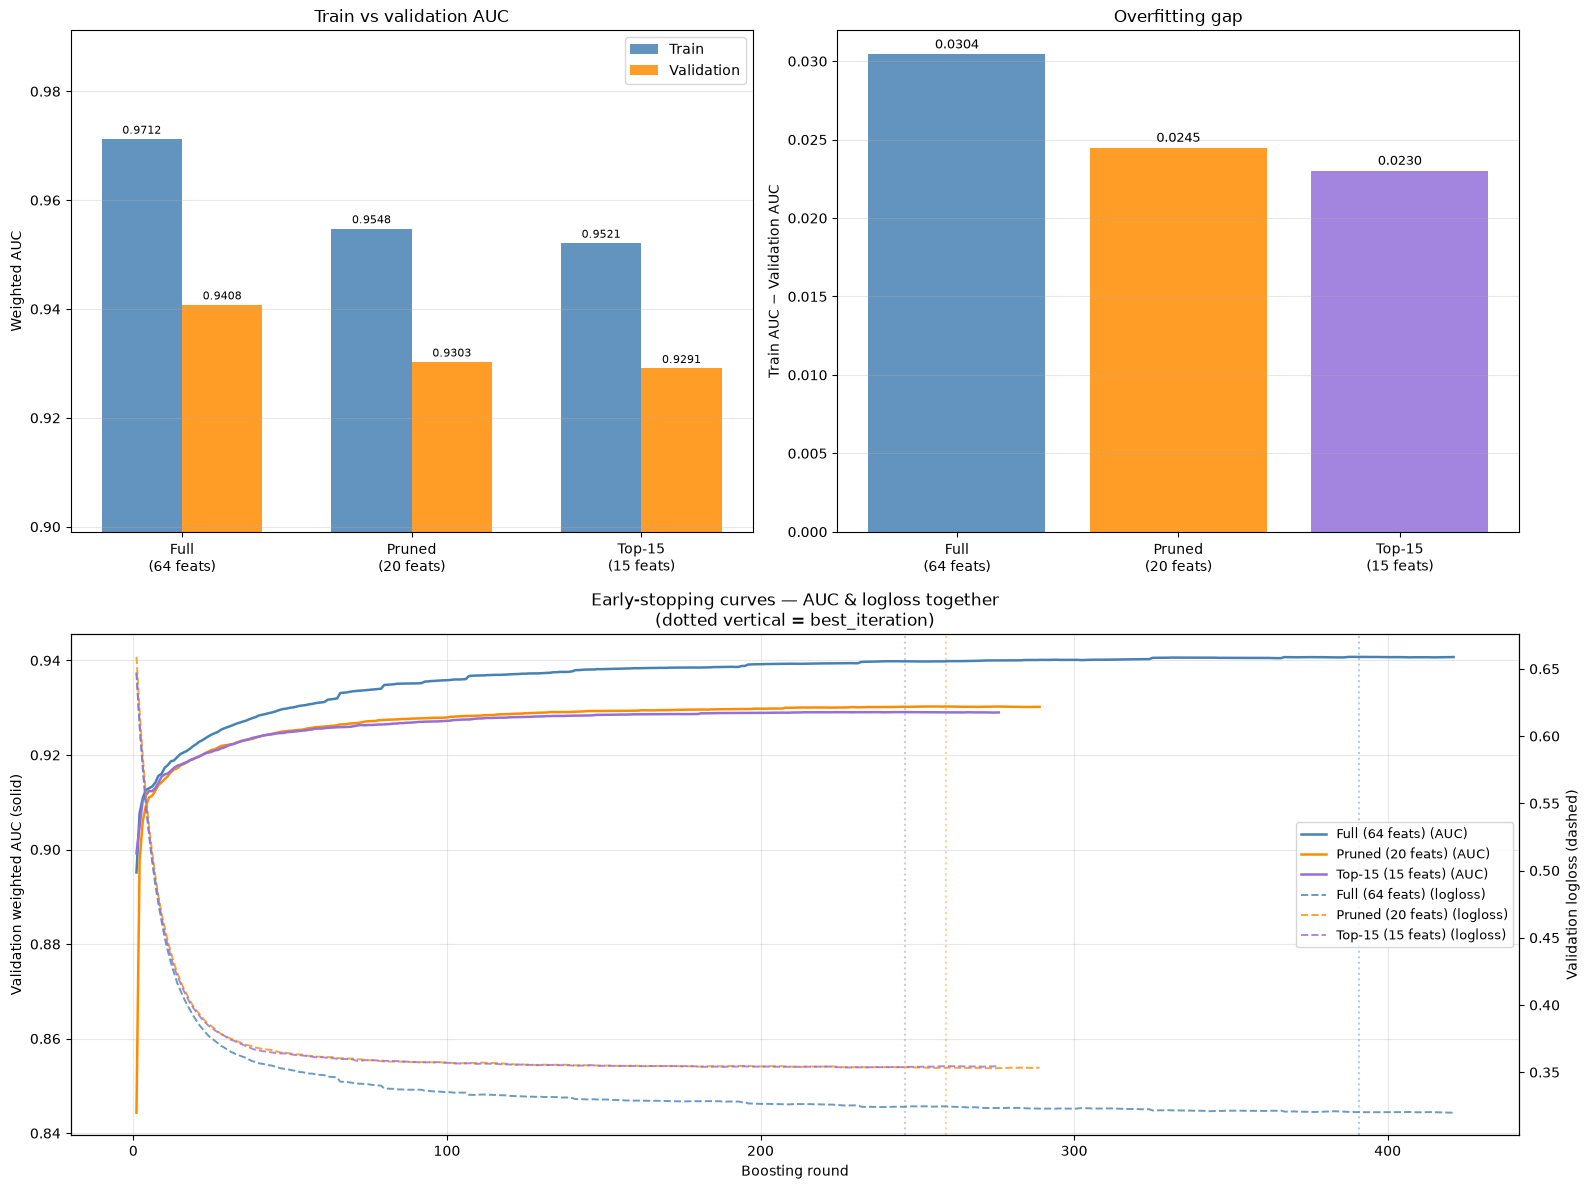

Model                #Features   Train AUC     Val AUC       Gap
Full                        64      0.9712      0.9408    0.0304
Pruned                      20      0.9548      0.9303    0.0245
Top-15                      15      0.9521      0.9291    0.0230


In [49]:
# ---- Model comparison — AUC & training curves (full vs pruned vs top-15) ---
model_names_comb = [f"Full\n({len(features_comb)} feats)", f"Pruned\n({len(PRUNED_FEATURES_COMB)} feats)",
                     f"Top-15\n({len(TOP15_FEATURES_COMB)} feats)"]
colors_comb = ["steelblue", "darkorange", "mediumpurple"]
train_aucs_comb = [auc_train_comb, auc_train_comb_pruned, auc_train_comb_top15]
val_aucs_comb = [auc_val_comb, auc_val_comb_pruned, auc_val_comb_top15]
models_fitted_comb = [model_comb, model_comb_pruned, model_comb_top15]

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)
ax_bars = fig.add_subplot(gs[0, 0])
ax_gap = fig.add_subplot(gs[0, 1])
ax_auc = fig.add_subplot(gs[1, :])   # wide combined panel, spans both columns

# --- Panel (0,0): train vs validation AUC, grouped bars --------------------
x = np.arange(len(model_names_comb))
width = 0.35
b1 = ax_bars.bar(x - width/2, train_aucs_comb, width, label="Train", color="steelblue", alpha=0.85)
b2 = ax_bars.bar(x + width/2, val_aucs_comb, width, label="Validation", color="darkorange", alpha=0.85)
for bars in (b1, b2):
    ax_bars.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
ax_bars.set_xticks(x)
ax_bars.set_xticklabels(model_names_comb)
ax_bars.set_ylabel("Weighted AUC")
ax_bars.set_ylim(min(val_aucs_comb) - 0.03, max(train_aucs_comb) + 0.02)
ax_bars.set_title("Train vs validation AUC")
ax_bars.legend()
ax_bars.grid(axis="y", alpha=0.3)

# --- Panel (0,1): overfitting gap (train - validation AUC) -----------------
gaps_comb = [t - v for t, v in zip(train_aucs_comb, val_aucs_comb)]
bars = ax_gap.bar(model_names_comb, gaps_comb, color=colors_comb, alpha=0.85)
ax_gap.bar_label(bars, fmt="%.4f", fontsize=9, padding=2)
ax_gap.set_ylabel("Train AUC − Validation AUC")
ax_gap.set_title("Overfitting gap")
ax_gap.grid(axis="y", alpha=0.3)

# --- Panel (1, :): validation AUC + logloss vs boosting round --------------
ax_loss = ax_auc.twinx()
for name, mdl, color in zip(model_names_comb, models_fitted_comb, colors_comb):
    label = name.replace("\n", " ")
    auc_curve = mdl.evals_result()["validation_0"]["auc"]
    loss_curve = mdl.evals_result()["validation_0"]["logloss"]
    rounds = np.arange(1, len(auc_curve) + 1)
    ax_auc.plot(rounds, auc_curve, color=color, linestyle="-", linewidth=1.8, label=f"{label} (AUC)")
    ax_loss.plot(rounds, loss_curve, color=color, linestyle="--", linewidth=1.4, alpha=0.8, label=f"{label} (logloss)")
    ax_auc.axvline(mdl.best_iteration + 1, color=color, linestyle=":", alpha=0.4)

ax_auc.set_xlabel("Boosting round")
ax_auc.set_ylabel("Validation weighted AUC (solid)")
ax_loss.set_ylabel("Validation logloss (dashed)")
ax_auc.set_title("Early-stopping curves — AUC & logloss together\n(dotted vertical = best_iteration)")
ax_auc.grid(alpha=0.3)

lines_auc, labels_auc = ax_auc.get_legend_handles_labels()
lines_loss, labels_loss = ax_loss.get_legend_handles_labels()
ax_auc.legend(lines_auc + lines_loss, labels_auc + labels_loss, fontsize=9, loc="center right")

plt.tight_layout()
plt.show()

print(f"{'Model':<20s}{'#Features':>10s}{'Train AUC':>12s}{'Val AUC':>12s}{'Gap':>10s}")
for name, feats, tr, va in zip(["Full", "Pruned", "Top-15"],
                                [features_comb, PRUNED_FEATURES_COMB, TOP15_FEATURES_COMB],
                                train_aucs_comb, val_aucs_comb):
    print(f"{name:<20s}{len(feats):>10d}{tr:>12.4f}{va:>12.4f}{tr - va:>10.4f}")


### Optuna tuning (Combined)

Not present in the original `Combined_Runs.ipynb` - added here for parity
with the Run 2 / Run 3 tracks, using the exact same reusable search function.
This is arguably the most important track to tune, since it has the most
statistical power (both campaigns combined).


In [50]:
# ---- Optuna hyperparameter search (Combined) --------------------------------
OPTUNA_FEATURES_COMB = PRUNED_FEATURES_COMB.copy()

study_comb = run_optuna_search(
    data_comb, OPTUNA_FEATURES_COMB, target_yields_comb, cell_cols=("run",),
    n_trials=N_OPTUNA_TRIALS, n_folds=N_FOLDS,
    base_n_estimators=800, study_name="xgb_1l2tau_combined",
)


/tmp/ipykernel_108492/844790540.py:106: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[xgb_1l2tau_combined] completed trials: 15
[xgb_1l2tau_combined] best mean CV significance Z (5 eventNumber-folds): 0.08259
[xgb_1l2tau_combined] mean best iteration: 465
[xgb_1l2tau_combined] fold Z's: [0.07425724903133822, 0.08166882959537528, 0.09789567825370853, 0.08343618302040744, 0.07569477242594626]
[xgb_1l2tau_combined] best parameters:
    learning_rate: 0.057161021316138726
    max_depth: 7
    min_child_weight: 2.1839352923182975
    subsample: 0.8056937753654446
    colsample_bytree: 0.836965827544817
    gamma: 0.23225206359998862
    reg_alpha: 0.10907475835157694
    reg_lambda: 0.2885622361859737


[Combined fold0] best_iteration=363 | weighted AUC: train=0.9606 val=0.9310
[Combined] fold 0: test_fold=0 val_fold=1 | train n=1080597 (dropped 127869 neg) | test weighted AUC = 0.9363 | test significance Z = 0.074
[Combined fold1] best_iteration=458 | weighted AUC: train=0.9644 val=0.9356
[Combined] fold 1: test_fold=1 val_fold=2 | train n=1080342 (dropped 128076 neg) | test weighted AUC = 0.9368 | test significance Z = 0.081
[Combined fold2] best_iteration=410 | weighted AUC: train=0.9618 val=0.9351
[Combined] fold 2: test_fold=2 val_fold=3 | train n=1080754 (dropped 128368 neg) | test weighted AUC = 0.9385 | test significance Z = 0.091
[Combined fold3] best_iteration=450 | weighted AUC: train=0.9637 val=0.9339
[Combined] fold 3: test_fold=3 val_fold=4 | train n=1082111 (dropped 128358 neg) | test weighted AUC = 0.9389 | test significance Z = 0.082
[Combined fold4] best_iteration=356 | weighted AUC: train=0.9603 val=0.9326
[Combined] fold 4: test_fold=4 val_fold=0 | train n=1082316 

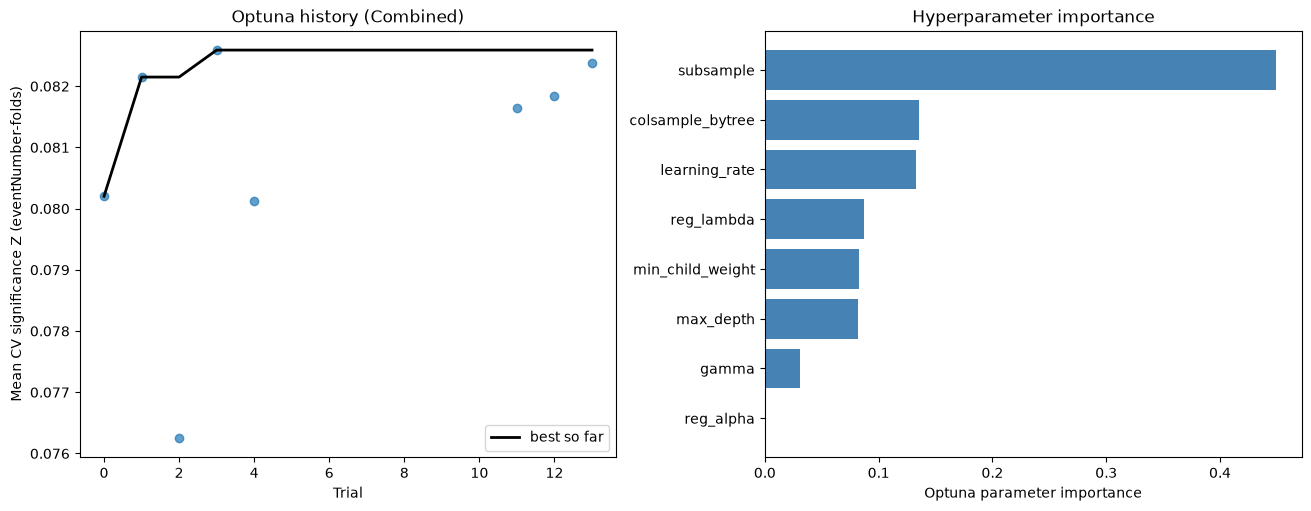

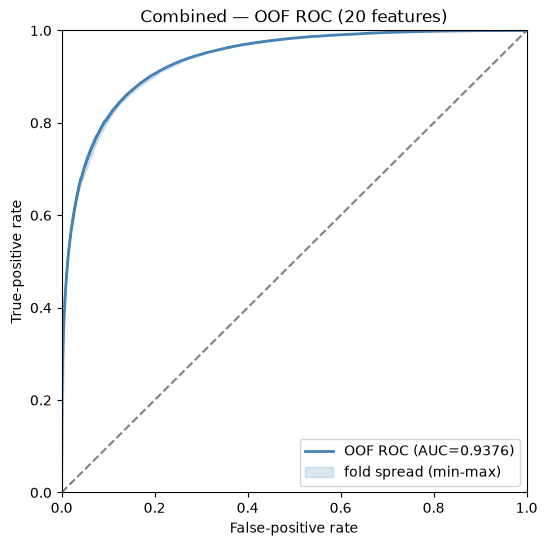

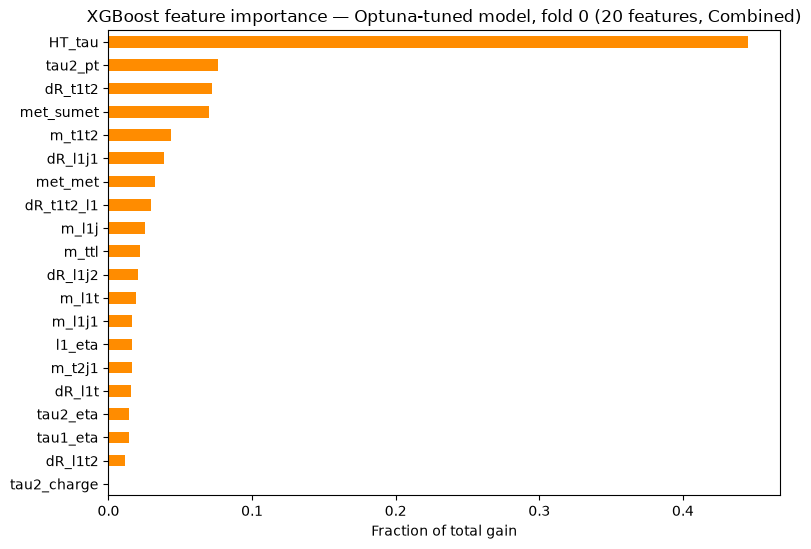

In [51]:
# ---- Final 5-fold OOF models + diagnostics (Combined) -----------------------
best_params_comb = params_from_study(study_comb)
oof_df_comb, models_comb = run_kfold_xgb(
    data_comb, OPTUNA_FEATURES_COMB, best_params_comb, target_yields_comb,
    cell_cols=("run",), n_folds=N_FOLDS, label="Combined",
)

plot_optuna_diagnostics(study_comb, title_suffix="(Combined)")
oof_auc_comb = plot_oof_roc(oof_df_comb, title=f"Combined — OOF ROC ({len(OPTUNA_FEATURES_COMB)} features)")

final_imp_comb = get_importance(models_comb[0], OPTUNA_FEATURES_COMB)
plot_importance_bar(
    final_imp_comb, top_n=len(OPTUNA_FEATURES_COMB),
    title=f"XGBoost feature importance — Optuna-tuned model, fold 0 ({len(OPTUNA_FEATURES_COMB)} features, Combined)",
    color="darkorange",
)


In [52]:
# ---- Persist the Combined fold models + feature list + hyperparams + OOF ---
save_track_artifacts(models_comb, OPTUNA_FEATURES_COMB, best_params_comb, oof_df_comb, BASE_DIR_COMB, "combined")


Saved 5 fold models + feature list + hyperparams + OOF scores -> PPSSP_2026/1l2tau/combined/ (track=combined)


### Did the ranking change? Run 2-only vs Run 3-only vs Combined

Compare where each of the Combined track's tuned features lands in the Run
2-only and Run 3-only tuned rankings (Sections 3/4) — a large rank shift for
a feature would be a warning sign that it behaves inconsistently between
campaigns.


In [53]:
# ---- Rank comparison across the three tuned tracks --------------------------
combined_rank = {feat: i + 1 for i, feat in enumerate(final_imp_comb.index)}
run2_rank = {feat: i + 1 for i, feat in enumerate(final_imp_r2.index)}
run3_rank = {feat: i + 1 for i, feat in enumerate(final_imp_r3.index)}

rows = []
for feat in OPTUNA_FEATURES_COMB:
    rows.append({
        "feature": feat,
        "combined_rank": combined_rank.get(feat),
        "run2_only_rank": run2_rank.get(feat, "not kept"),
        "run3_only_rank": run3_rank.get(feat, "not kept"),
    })
rank_compare = pd.DataFrame(rows).set_index("feature")
print(f"Combined-track top-{len(OPTUNA_FEATURES_COMB)} features vs. their rank in the "
      f"Run2-only / Run3-only tuned models:")
print(rank_compare.to_string())

# Simple rank-shift summary (only where the feature survived pruning in both
# single-run tracks too)
comparable = rank_compare[
    pd.to_numeric(rank_compare["run2_only_rank"], errors="coerce").notna()
    & pd.to_numeric(rank_compare["run3_only_rank"], errors="coerce").notna()
].astype({"run2_only_rank": float, "run3_only_rank": float})
rank_shift = ((comparable["combined_rank"] - comparable["run2_only_rank"]).abs()
              + (comparable["combined_rank"] - comparable["run3_only_rank"]).abs()) / 2
if len(rank_shift):
    print(f"\nMean |rank shift| vs combined (averaged over Run2/Run3): {rank_shift.mean():.1f} positions")
    print(f"Max |rank shift|: {rank_shift.max():.0f} positions ({rank_shift.idxmax()})")


Combined-track top-20 features vs. their rank in the Run2-only / Run3-only tuned models:
             combined_rank run2_only_rank run3_only_rank
feature                                                 
HT_tau                   1              1              1
dR_t1t2                  3              3              3
tau2_pt                  2              4              2
m_t1t2                   5              5              5
met_sumet                4              2              4
dR_l1j1                  6              6              6
m_l1j                    9              9              9
met_met                  7              7              7
m_l1j1                  13             11             12
m_ttl                   10             10             11
m_l1t                   12             15             13
dR_t1t2_l1               8              8              8
dR_l1t                  16             17             16
dR_l1j2                 11             12             10

## 6. Run 2 vs Run 3 — Domain-Shift Check

A separate, lightweight XGBoost model whose only job is telling **Run 2**
signal events (ggF + VBF) apart from **Run 3** signal events. This is
completely independent from the signal-vs-background classifiers trained in
Sections 3-5 - nothing there is touched or reused as a model, only their
*feature list* is reused (the Combined track's tuned, decorrelated features,
persisted to disk in Section 5), so the test reflects exactly the variables
that would feed the final analysis.

**Label convention:** Run 2 = 0, Run 3 = 1. **Weights:** the raw `weights`
branch is used AS-IS (not `weight * weights`, unlike `w_phys` elsewhere) -
this test cares about the shape of the per-event generator weight, not the
physical yield.

**How to read the resulting AUC:** AUC ≈ 0.5 → the classifier can't tell the
runs apart → the feature distributions are effectively the same between Run 2
and Run 3. AUC well above 0.5 → a genuine distribution shift, and `AUC - 0.5`
is roughly its effect size.


In [54]:
# ---- Feature set to test for a Run2/Run3 shift ------------------------------
# Uses the Combined track's tuned, decorrelated feature set (persisted to
# disk in Section 5 by save_track_artifacts) - these are the features that
# would actually go into the final analysis, so this checks exactly the
# variables that matter. Loaded from disk (rather than reusing the in-memory
# variable) so this section can also be run on its own after a kernel restart.
FEATURES_PATH_DOMAIN = BASE_DIR_COMB / "features_combined.json"
with open(FEATURES_PATH_DOMAIN) as f:
    domain_features = json.load(f)

print(f"Loaded {len(domain_features)} features from {FEATURES_PATH_DOMAIN}:")
print(domain_features)

SIGNAL_FILES = {"signal_ggF": "signal_ggF.root", "signal_VBF": "signal_VBF.root"}
WEIGHT_BRANCH = "weights"   # raw per-event branch, used AS-IS as sample_weight

# Sanity check: confirm every feature exists in all four signal files
# (ggF + VBF, Run2 + Run3) before we try to read them.
common_domain = None
for base_dir in (BASE_DIR_R2, BASE_DIR_R3):
    for fname in SIGNAL_FILES.values():
        keys = set(uproot.open({str(base_dir / fname): TREE_NAME}).keys())
        common_domain = keys if common_domain is None else common_domain & keys
missing = [f for f in domain_features if f not in common_domain]
if missing:
    raise ValueError(f"Features missing from one or more signal files: {missing}")


Loaded 20 features from PPSSP_2026/1l2tau/combined/features_combined.json:
['HT_tau', 'dR_t1t2', 'tau2_pt', 'm_t1t2', 'met_sumet', 'dR_l1j1', 'm_l1j', 'met_met', 'm_l1j1', 'm_ttl', 'm_l1t', 'dR_t1t2_l1', 'dR_l1t', 'dR_l1j2', 'tau2_eta', 'l1_eta', 'tau1_eta', 'tau2_charge', 'dR_l1t2', 'm_t2j1']


In [55]:
# ---- Load Run2 + Run3 signal events (label: Run2=0, Run3=1) -----------------
frames = []
for run_label, run_name, base_dir in [(0, "Run 2", BASE_DIR_R2), (1, "Run 3", BASE_DIR_R3)]:
    for proc, fname in SIGNAL_FILES.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        df["process"] = proc
        frames.append(df)
        print(f"{run_name:5s} {proc:12s}: {len(df):>8d} events after preselection")

domain_data = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(domain_data)} events "
      f"(Run 2 = {(domain_data.run_label == 0).sum()}, Run 3 = {(domain_data.run_label == 1).sum()})")

# ---- Post-concat cleaning: constant features + sentinel -> NaN -------------
domain_data, domain_features = clean_data(domain_data, domain_features)

# ---- Sanity check: weight sums & negative-weight fractions ------------------
# Comparable total weight -> comparable effective normalization between runs.
# Negative weights are reported but NOT dropped (Sherpa NLO interference
# effects are physical, not a data-quality issue).
for run_label, run_name in [(0, "Run 2"), (1, "Run 3")]:
    subset = domain_data.loc[domain_data.run_label == run_label, WEIGHT_BRANCH]
    total_w = subset.sum()
    neg_frac = (subset < 0).mean()
    print(f"{run_name}: sum({WEIGHT_BRANCH}) = {total_w:12.4f} | "
          f"negative-weight fraction = {neg_frac:6.2%} | n_events = {len(subset)}")


Run 2 signal_ggF  :    67075 events after preselection
Run 2 signal_VBF  :    21639 events after preselection
Run 3 signal_ggF  :   191580 events after preselection
Run 3 signal_VBF  :    13470 events after preselection

Total: 293764 events (Run 2 = 88714, Run 3 = 205050)
Dropped 0 constant/empty features:
  []

20 final features
Run 2: sum(weights) =    1848.0950 | negative-weight fraction =  4.58% | n_events = 88714
Run 3: sum(weights) =    5227.1216 | negative-weight fraction =  5.80% | n_events = 205050


In [56]:
# ---- Build training arrays ---------------------------------------------------
X = domain_data[domain_features]
y = domain_data["run_label"].to_numpy()
w_raw = domain_data[WEIGHT_BRANCH].to_numpy()   # raw branch, AS-IS
w_abs = np.abs(w_raw)

# --- Class balance ------------------------------------------------------------
# Run 2 and Run 3 can have different total weight (see sanity check above);
# rescale per-event weights so both runs contribute equal total weight,
# otherwise the AUC would partly reflect a normalization difference rather
# than a genuine shape difference (mirrors make_fit_weights, but keyed on
# run_label instead of label).
w_fit = w_abs.copy()
sum_r2, sum_r3 = w_fit[y == 0].sum(), w_fit[y == 1].sum()
w_fit[y == 1] *= sum_r2 / sum_r3
w_fit *= len(w_fit) / w_fit.sum()

print(f"Run2/Run3 total-weight ratio before balancing: {sum_r2 / sum_r3:.3f}")
print(f"Run2/Run3 total-weight ratio after balancing:  {w_fit[y == 0].sum() / w_fit[y == 1].sum():.3f}")


Run2/Run3 total-weight ratio before balancing: 0.351
Run2/Run3 total-weight ratio after balancing:  1.000


In [57]:
# ---- Stratified K-Fold cross-validation --------------------------------------
# AUC is computed ONLY on each held-out fold. IMPORTANT: no early stopping /
# eval_set here - that would let XGBoost pick best_iteration to maximize AUC
# on the exact fold being scored, an upward-biasing leak that matters a lot
# when the whole point is testing "is AUC ~ 0.5".
N_FOLDS_DOMAIN = 5
cv = StratifiedKFold(n_splits=N_FOLDS_DOMAIN, shuffle=True, random_state=RANDOM_STATE)

fold_aucs = []
for fold, (idx_tr, idx_te) in enumerate(cv.split(X, y), start=1):
    fold_model = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
    )
    fold_model.fit(X.iloc[idx_tr], y[idx_tr], sample_weight=w_fit[idx_tr], verbose=False)
    pred = fold_model.predict_proba(X.iloc[idx_te])[:, 1]
    fold_auc = roc_auc_score(y[idx_te], pred, sample_weight=w_abs[idx_te])
    fold_aucs.append(fold_auc)
    print(f"Fold {fold}/{N_FOLDS_DOMAIN}: weighted AUC = {fold_auc:.4f}")

fold_aucs = np.array(fold_aucs)
print(f"\nMean weighted AUC across {N_FOLDS_DOMAIN} folds: {fold_aucs.mean():.4f} \u00b1 {fold_aucs.std():.4f}")
print("(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)")


Fold 1/5: weighted AUC = 0.5345
Fold 2/5: weighted AUC = 0.5470
Fold 3/5: weighted AUC = 0.5468
Fold 4/5: weighted AUC = 0.5411
Fold 5/5: weighted AUC = 0.5422

Mean weighted AUC across 5 folds: 0.5423 ± 0.0046
(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)


Held-out AUC of this single interpretation model: 0.5345 (compare to the 5-fold mean above)


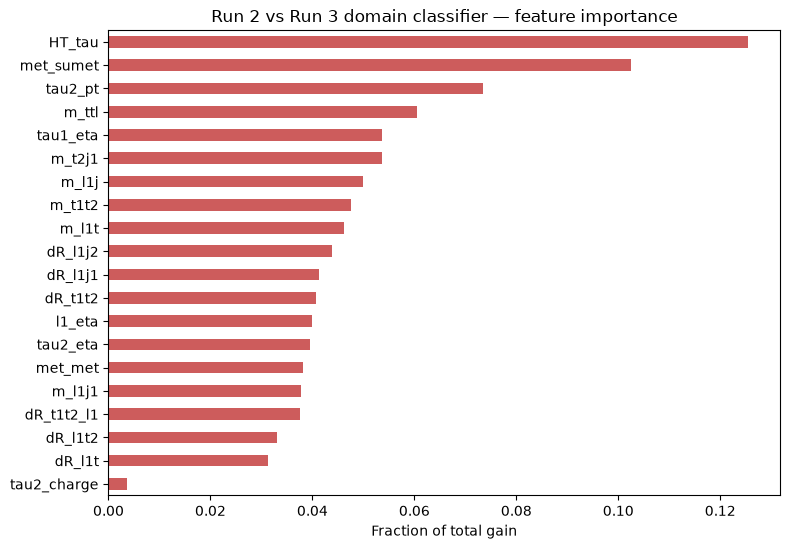

In [58]:
# ---- Final model (single split) + feature importance -------------------------
# The k-fold result above is the AUC estimate to quote - this single model is
# only to get one clean feature-importance / SHAP picture.
train_idx, test_idx = next(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y))

final_domain_model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)
final_domain_model.fit(X.iloc[train_idx], y[train_idx], sample_weight=w_fit[train_idx], verbose=False)

pred_test = final_domain_model.predict_proba(X.iloc[test_idx])[:, 1]
auc_test_domain = roc_auc_score(y[test_idx], pred_test, sample_weight=w_abs[test_idx])
print(f"Held-out AUC of this single interpretation model: {auc_test_domain:.4f} "
      f"(compare to the {N_FOLDS_DOMAIN}-fold mean above)")

imp_domain = get_importance(final_domain_model, domain_features)
plot_importance_bar(imp_domain, top_n=len(domain_features),
                     title="Run 2 vs Run 3 domain classifier — feature importance", color="indianred")


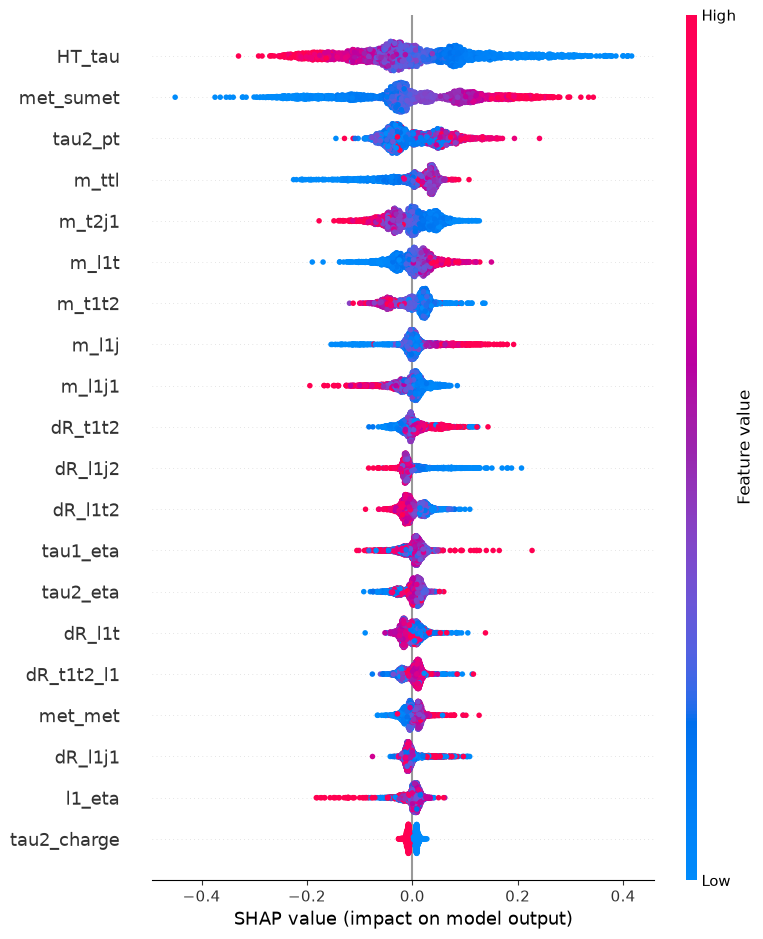

In [59]:
# ---- SHAP values (optional - requires `pip install shap`) --------------------
# Subsample for speed; TreeExplainer is exact for tree models, so a moderate
# sample is enough to see the global pattern.
try:
    import shap

    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(len(X), size=min(3000, len(X)), replace=False)
    X_shap = X.iloc[sample_idx]

    explainer = shap.TreeExplainer(final_domain_model)
    shap_values = explainer.shap_values(X_shap)
    shap.summary_plot(shap_values, X_shap, max_display=20, show=True)
except ImportError:
    print("`shap` is not installed - skip this cell or `pip install shap` to see per-feature SHAP values.")


### All-processes scan

Repeat the same two-sample test independently for **every** simulated process
(not just the combined signal), to see whether Run2/Run3 differences are
localized to specific backgrounds or general across the production. Same
features, preselection and weight handling as above - just looped over every
ROOT file in `FILES` (Section 1).

Outputs: `run2_vs_run3_auc_summary.csv` (one row per process) and one
`run2_vs_run3_plots/<process>_importance.png` per process.


In [60]:
PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)
RESULTS_CSV_DOMAIN = Path("run2_vs_run3_auc_summary.csv")


def run_two_sample_test(process_name, fname, features=domain_features, n_folds=3,
                         n_estimators=200, plots_dir=PLOTS_DIR_DOMAIN):
    """Run2-vs-Run3 domain classifier for a single process (one ROOT file per
    run). Saves a feature-importance PNG and returns a summary dict. Lighter
    hyperparameters than the signal-only test above since this runs once per
    process - it's a scan, not the final result. No early stopping here
    either, for the same leakage reasons as the k-fold loop above.
    """
    frames = []
    for run_label, base_dir in [(0, BASE_DIR_R2), (1, BASE_DIR_R3)]:
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
    data = pd.concat(frames, ignore_index=True)

    # Sentinel -> NaN only (no constant-feature dropping - every process must
    # keep the exact same feature set so results stay comparable).
    for feat in features:
        m = data[feat] < -100
        if m.any():
            data[feat] = data[feat].mask(m)

    n_r2 = int((data.run_label == 0).sum())
    n_r3 = int((data.run_label == 1).sum())

    X_proc = data[features]
    y_proc = data["run_label"].to_numpy()
    w_raw_proc = data[WEIGHT_BRANCH].to_numpy()
    w_abs_proc = np.abs(w_raw_proc)

    sum_w_r2 = w_raw_proc[y_proc == 0].sum()
    sum_w_r3 = w_raw_proc[y_proc == 1].sum()
    neg_frac_r2 = (w_raw_proc[y_proc == 0] < 0).mean() if n_r2 else np.nan
    neg_frac_r3 = (w_raw_proc[y_proc == 1] < 0).mean() if n_r3 else np.nan

    w_fit_proc = w_abs_proc.copy()
    sum_abs_r2, sum_abs_r3 = w_fit_proc[y_proc == 0].sum(), w_fit_proc[y_proc == 1].sum()
    if sum_abs_r2 > 0 and sum_abs_r3 > 0:
        w_fit_proc[y_proc == 1] *= sum_abs_r2 / sum_abs_r3
        w_fit_proc *= len(w_fit_proc) / w_fit_proc.sum()

    n_splits = min(n_folds, n_r2, n_r3)
    fold_aucs = []
    if n_splits >= 2:
        cv_proc = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        for idx_tr, idx_te in cv_proc.split(X_proc, y_proc):
            fold_model = xgb.XGBClassifier(
                n_estimators=n_estimators, learning_rate=0.05, max_depth=4,
                subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
            )
            fold_model.fit(X_proc.iloc[idx_tr], y_proc[idx_tr], sample_weight=w_fit_proc[idx_tr], verbose=False)
            pred = fold_model.predict_proba(X_proc.iloc[idx_te])[:, 1]
            fold_aucs.append(roc_auc_score(y_proc[idx_te], pred, sample_weight=w_abs_proc[idx_te]))

    fold_aucs = np.array(fold_aucs)
    mean_auc = float(fold_aucs.mean()) if len(fold_aucs) else np.nan
    std_auc = float(fold_aucs.std()) if len(fold_aucs) else np.nan

    final = xgb.XGBClassifier(
        n_estimators=n_estimators, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
    )
    final.fit(X_proc, y_proc, sample_weight=w_fit_proc, verbose=False)
    imp_proc = get_importance(final, features)

    fig, ax = plt.subplots(figsize=(8, 8))
    imp_proc["gain_frac"][::-1].plot.barh(ax=ax, color="teal")
    ax.set_xlabel("Fraction of total gain")
    ax.set_title(f"Run 2 vs Run 3 — {process_name} — feature importance")
    plt.tight_layout()
    fig.savefig(plots_dir / f"{process_name}_importance.png", dpi=150)
    plt.close(fig)

    # A suspiciously high AUC dominated by one variable can be an artifact of
    # that variable's NaN *fraction* differing between runs (not its value) -
    # track that here so it can be sanity-checked before trusting the result.
    top_feature = imp_proc.index[0] if len(imp_proc) else None
    if top_feature is not None:
        nan_frac_r2 = data.loc[data.run_label == 0, top_feature].isna().mean()
        nan_frac_r3 = data.loc[data.run_label == 1, top_feature].isna().mean()
    else:
        nan_frac_r2 = nan_frac_r3 = np.nan

    print(f"{process_name:12s}: Run2 = {n_r2:>7d} | Run3 = {n_r3:>7d} | "
          f"weighted AUC = {mean_auc:.4f} \u00b1 {std_auc:.4f} ({n_splits} folds) | "
          f"top feature = {top_feature} (NaN frac Run2={nan_frac_r2:.1%}, Run3={nan_frac_r3:.1%})")

    return {
        "process": process_name, "n_run2": n_r2, "n_run3": n_r3,
        "sum_weights_run2": sum_w_r2, "sum_weights_run3": sum_w_r3,
        "neg_weight_frac_run2": neg_frac_r2, "neg_weight_frac_run3": neg_frac_r3,
        "n_folds": n_splits, "mean_auc": mean_auc, "std_auc": std_auc,
        "top_feature": top_feature,
        "top_feature_gain_frac": imp_proc["gain_frac"].iloc[0] if len(imp_proc) else np.nan,
        "top_feature_nan_frac_run2": nan_frac_r2, "top_feature_nan_frac_run3": nan_frac_r3,
    }


In [61]:
# ---- Run the scan over every process and export the summary ----------------
results = [run_two_sample_test(proc, fname) for proc, (fname, _label) in FILES.items()]

results_df = pd.DataFrame(results).sort_values("mean_auc", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_CSV_DOMAIN, index=False)

print(f"\nSaved AUC summary ({len(results_df)} processes) -> {RESULTS_CSV_DOMAIN}")
print(f"Saved {len(FILES)} feature-importance PNGs -> {PLOTS_DIR_DOMAIN}/")
results_df


signal_ggF  : Run2 =   67075 | Run3 =  191580 | weighted AUC = 0.5419 ± 0.0010 (3 folds) | top feature = HT_tau (NaN frac Run2=0.0%, Run3=0.0%)
signal_VBF  : Run2 =   21639 | Run3 =   13470 | weighted AUC = 0.5126 ± 0.0022 (3 folds) | top feature = met_sumet (NaN frac Run2=0.0%, Run3=0.0%)
Diboson     : Run2 =  312600 | Run3 =  628676 | weighted AUC = 0.5403 ± 0.0012 (3 folds) | top feature = HT_tau (NaN frac Run2=0.0%, Run3=0.0%)


KeyboardInterrupt: 

## 7. Summary


In [ ]:
# ---- Consolidated AUC comparison across all three tracks --------------------
# "baseline"/"pruned" are fold-0-preview single-split numbers (feature-
# selection diagnostics only); "tuned" is now the pooled OOF weighted AUC
# from the full 5-fold rotation (every event scored by a model that never
# trained on it) - not a single held-out split like the old "tuned" column.
summary_rows = [
    {"track": "Run 2",    "baseline": auc_val_r2,   "pruned": auc_val_r2_pruned,   "tuned_OOF": oof_auc_r2},
    {"track": "Run 3",    "baseline": auc_val_r3,   "pruned": auc_val_r3_pruned,   "tuned_OOF": oof_auc_r3},
    {"track": "Combined", "baseline": auc_val_comb, "pruned": auc_val_comb_pruned, "tuned_OOF": oof_auc_comb},
]
summary_df = pd.DataFrame(summary_rows).set_index("track")
print("Weighted AUC by track and feature-selection stage (baseline/pruned = fold-0 preview, tuned_OOF = full 5-fold OOF):")
print(summary_df.to_string(float_format=lambda x: f"{x:.4f}"))

fig, ax = plt.subplots(figsize=(8, 5))
summary_df.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Weighted AUC")
ax.set_title("Signal-vs-background BDT — AUC by track & stage")
ax.set_ylim(summary_df.values.min() - 0.02, summary_df.values.max() + 0.02)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRun2 vs Run3 domain-shift check (signal, combined-track features): "
      f"mean weighted AUC = {fold_aucs.mean():.4f} \u00b1 {fold_aucs.std():.4f}")
print("(closer to 0.5 = the two campaigns agree better on the features that matter)")
print("\nPer-process domain-shift AUCs (highest first):")
print(results_df[["process", "mean_auc", "std_auc", "top_feature"]].to_string(index=False))


### Artifacts written to disk

| Path | Contents |
| --- | --- |
| `PPSSP_2026/1l2tau/run2/final_model_run2.json` | Run-2 tuned XGBoost model |
| `PPSSP_2026/1l2tau/run2/optuna_features_run2.json` | Run-2 tuned feature list |
| `PPSSP_2026/1l2tau/run2/splits/{train,val}.root` | Run-2 train/val split |
| `PPSSP_2026/1l2tau/run3/final_model_run3.json` | Run-3 tuned XGBoost model |
| `PPSSP_2026/1l2tau/run3/optuna_features_run3.json` | Run-3 tuned feature list |
| `PPSSP_2026/1l2tau/run3/splits/{train,val}.root` | Run-3 train/val split |
| `PPSSP_2026/1l2tau/combined/final_model_combined.json` | Combined tuned XGBoost model |
| `PPSSP_2026/1l2tau/combined/optuna_features_combined.json` | Combined tuned feature list |
| `run2_vs_run3_auc_summary.csv` | Per-process Run2/Run3 domain-shift AUC |
| `run2_vs_run3_plots/*.png` | Per-process feature-importance plots |

### Provenance

This notebook consolidates and replaces, for the **1l2tau** channel:
`First_Training.ipynb`, `Combined_Runs.ipynb`, the 1l2tau section of
`Comparison.ipynb`, and `Yields.ipynb`. Left out of this pass:

- The **2l2tau** channel (not requested for this notebook).
- `1L2TRun2.ipynb` - early PyROOT/TChain exploration and plotting utilities,
  superseded by the uproot-based pipeline here.
- `WEights.ipynb` - an earlier draft of the weight handling that used an
  outdated branch name (`weight_final` instead of `weights`); superseded by
  Section 2's `make_fit_weights` / `load_run_data`.

### Suggested next steps

- Run this notebook top-to-bottom once to populate every output (it has not
  been executed yet).
- If Section 6's AUC is well above 0.5 for a specific process, inspect that
  process's row in `results_df` / saved PNG before trusting a Run2+Run3 merge
  for it.
- To extend this to the **2l2tau** channel, copy Section 1's configuration
  block and adjust `BASE_DIR_*`, `PRESELECTION` and the blocklist for the
  2l2tau branch names - Section 2's helper functions are channel-agnostic and
  can be reused as-is.
